# 🎓 EWU Chatbot Pipeline — Notebook B (RAG · Cache · Ablation · Judge)

**Continues from Notebook A** (data → baseline → fine-tuning → fine-tuned eval),
run in a separate Kaggle session to stay under the 12-hour limit.

This notebook:
1. Reinstalls its own deps (RAG/eval libs — separate from Notebook A's training stack)
2. Reloads the tokenizer + 4-bit base model, then re-attaches the saved LoRA adapter
3. Reloads the eval set + baseline/fine-tuned predictions/metrics saved by Notebook A
   (§16.1 handoff) instead of recomputing them
4. Continues the pipeline unchanged from §17 (RAG) through §25 (reproducibility export)

**Before running:** edit `HANDOFF_PATH` and `ADAPTER_CHECKPOINT_DIR` in the next cell
to match wherever you kept Notebook A's `/kaggle/working` output (re-attach it as a
Kaggle Dataset, or upload the `handoff.pkl` + adapter folder as one).


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# EDIT THESE TWO PATHS to point at Notebook A's saved output
# ══════════════════════════════════════════════════════════════════════════
HANDOFF_PATH           = "/kaggle/input/datasets/bxgdhdgsg/run111/ewu_qwen_lora/handoff_to_notebook_b/handoff.pkl"
ADAPTER_CHECKPOINT_DIR = "/kaggle/input/datasets/mrnotalent/7bbbbb/ewu7b/adapter"  # same adapter Notebook A trained/loaded

# Ground-truth XLSX + KB dir + other raw-data paths still need to be set for THIS session
# (they aren't part of the handoff since they're static input datasets, not computed state)
KB_DIR            = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/KB/KB"          # ← EDIT if needed
GROUND_TRUTH_XLSX = "/kaggle/input/datasets/mohuaakter/ewu-dataset-jsonl-pairs/University_Chatbot_Questions_1110_GROUND_TRUTHS_VERIFIED.xlsx"  # ← EDIT if needed
OUTPUT_DIR        = "/kaggle/working/ewu_qwen_lora"
PAPER_ASSETS_DIR  = "/kaggle/working/paper_assets"

## B.1 · Install Dependencies (base model + quantization stack)

In [2]:
%%capture
import os

cuda_lib = "/usr/local/cuda/lib64"
ld = os.environ.get("LD_LIBRARY_PATH", "")
if cuda_lib not in ld:
    os.environ["LD_LIBRARY_PATH"] = f"{cuda_lib}:{ld}"

!pip install -q -U \
    bitsandbytes \
    peft \
    transformers \
    accelerate \
    bert-score \
    rouge-score \
    sacrebleu \
    rapidfuzz \
    scipy \
    beautifulsoup4 \
    scikit-learn

## B.2 · Reload Handoff State + Base Model + Adapter
Reconstructs everything §17 onward expects (`test_prompts_eval`, `baseline_metrics`, `ft_predictions`, `model`, `tokenizer`, etc.) without re-running data loading, training, or the two eval passes from Notebook A.

In [3]:
import os
import pickle, random, warnings, time, math, re, glob, json, shutil, zipfile, platform, copy
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from tqdm.auto import tqdm

import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import sacrebleu
from rapidfuzz import process, fuzz as rf_fuzz
from scipy.stats import wilcoxon
from bs4 import BeautifulSoup


# Shared text normalization used by weak retrieval labels and other evaluation helpers.
def _norm(text):
    return " ".join(str(text or "").strip().lower().split())

warnings.filterwarnings('ignore')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PAPER_ASSETS_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── 1. Load handoff payload from Notebook A ─────────────────────────────────
with open(HANDOFF_PATH, "rb") as f:
    handoff = pickle.load(f)

test_prompts_eval    = handoff["test_prompts_eval"]
test_references_eval = handoff["test_references_eval"]
test_langs_eval       = handoff["test_langs_eval"]
eval_test_idx         = handoff["eval_test_idx"]

baseline_predictions = handoff["baseline_predictions"]
baseline_metrics      = handoff["baseline_metrics"]
baseline_per_sample   = handoff["baseline_per_sample"]
baseline_by_lang       = handoff["baseline_by_lang"]

ft_predictions      = handoff["ft_predictions"]
ft_metrics          = handoff["ft_metrics"]
ft_per_sample       = handoff["ft_per_sample"]
ft_metrics_by_lang  = handoff["ft_metrics_by_lang"]

SYSTEM_PROMPT         = handoff["SYSTEM_PROMPT"]
SEED                  = handoff["SEED"]
MODEL_ID              = handoff["MODEL_ID"]
MAX_SEQ_LEN           = handoff["MAX_SEQ_LEN"]
N_BOOTSTRAP           = handoff["N_BOOTSTRAP"]
BOOTSTRAP_CI          = handoff["BOOTSTRAP_CI"]
WEAK_LABEL_THRESHOLD  = handoff["WEAK_LABEL_THRESHOLD"]
CACHE_THRESHOLD_SWEEP = handoff["CACHE_THRESHOLD_SWEEP"]
CHUNK_SIZE            = handoff["CHUNK_SIZE"]
CHUNK_OVERLAP         = handoff["CHUNK_OVERLAP"]
TOP_K_DENSE           = handoff["TOP_K_DENSE"]
TOP_K_SPARSE          = handoff["TOP_K_SPARSE"]
TOP_K_FINAL           = handoff["TOP_K_FINAL"]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print(f"✅ Handoff loaded: {len(test_prompts_eval)}-item eval set, "
      f"baseline + fine-tuned predictions/metrics restored.")

# ── 2. Reload tokenizer + 4-bit base model + adapter ────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_CHECKPOINT_DIR, trust_remote_code=True, padding_side='right')
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print(f"Loading LoRA adapter from: {ADAPTER_CHECKPOINT_DIR}")
model = PeftModel.from_pretrained(base_model, ADAPTER_CHECKPOINT_DIR)
model.eval()
model.config.use_cache = True

print("✅ Base model + adapter reloaded. Ready to continue from §17 (RAG).")

# ── 3. Recreate §8's shared evaluation utilities (EWU_KEYWORDS, is_ewu_hit,
#    make_generate_fn, compute_all_metrics, bootstrap_ci, paired_bootstrap_p) ──
# These are DEFINITIONS from Notebook A's §8 — reused as-is by §20.1/§23/§24 below,
# since baseline_metrics/ft_metrics themselves came pre-computed via the handoff.
# ── EWU domain keywords for Domain Hit % ─────────────────────────────────────
EWU_KEYWORDS = [
    # English
    'ewu', 'east west university', 'admission', 'semester', 'tuition',
    'credit', 'cgpa', 'department', 'faculty', 'campus', 'lab', 'library',
    'registrar', 'scholarship', 'exam', 'midterm', 'final', 'course',
    'club', 'cafeteria', 'bus', 'hall', 'dean', 'proctor',
    # Bangla transliteration
    'bhortir', 'semester', 'porikhha', 'department', 'biswabidyalay',
    # Bangla script
    'ভর্তি', 'সেমিস্টার', 'পরীক্ষা', 'বিশ্ববিদ্যালয়', 'অনুষদ',
]

def is_ewu_hit(text: str) -> bool:
    t = text.lower()
    return any(kw in t for kw in EWU_KEYWORDS)

from transformers import LogitsProcessorList, InfNanRemoveLogitsProcessor

def make_generate_fn(gen_model):
    '''Bind a generate_response()-style function to a specific model instance
    (base model for the baseline, LoRA model for fine-tuned/per-seed runs).'''
    # Larger (7B) models sampled in fp16 on a T4 occasionally produce an inf/nan logit that
    # crashes torch.multinomial ("probability tensor contains inf, nan or element < 0").
    # InfNanRemoveLogitsProcessor sanitizes the logits before sampling so generation degrades
    # gracefully (that token's probability mass gets zeroed) instead of crashing the whole run.
    _safe_logits_processor = LogitsProcessorList([InfNanRemoveLogitsProcessor()])

    def _generate(prompt: str, max_new_tokens: int = 200) -> str:
        chat_input = (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{prompt}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )
        enc = tokenizer(chat_input, return_tensors="pt").to(gen_model.device)
        with torch.no_grad():
            out = gen_model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                temperature=0.3,
                top_p=0.9,
                do_sample=True,
                logits_processor=_safe_logits_processor,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.convert_tokens_to_ids('<|im_end|>'),
            )
        gen_ids  = out[0][enc['input_ids'].shape[1]:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        return response.strip()
    return _generate

# §22's cache benchmark ("generate_response(q)") calls a plain, uncached generation
# function bound to the loaded fine-tuned model -- mirroring Notebook A's cell 33
# ("generate_response = make_generate_fn(model)  # main generation function used from
# here on"). That assignment lived only in Notebook A's in-memory session and isn't
# part of the handoff, so it must be recreated here or §22 crashes with NameError.
generate_response = make_generate_fn(model)

def compute_all_metrics(predictions, references, langs=None):
    '''Compute the 8 core metrics plus per-sample scores (needed for bootstrap
    CIs and paired significance tests) and an optional per-language breakdown.
    Returns (metrics, per_sample, metrics_by_lang).'''
    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    r1, r2, rL = [], [], []
    for ref, pred in zip(references, predictions):
        sc = rouge.score(ref, pred)
        r1.append(sc['rouge1'].fmeasure)
        r2.append(sc['rouge2'].fmeasure)
        rL.append(sc['rougeL'].fmeasure)

    # Multilingual BERTScore checkpoint — the English-only default gives
    # meaningless scores on Bangla/Banglish text.
    _, _, F1_bert = bert_score_fn(
        predictions, references, model_type='bert-base-multilingual-cased',
        device=device, batch_size=8, verbose=False,
    )
    bert_f1_ps = F1_bert.tolist()

    exact   = [1 if p.strip().lower() == r.strip().lower() else 0 for p, r in zip(predictions, references)]
    gen_len = [len(p.split()) for p in predictions]
    domain_hit = [is_ewu_hit(p) for p in predictions]

    # chrF++ (character n-gram F-score + word bigrams): standard in MT/NLG evaluation and
    # notably more reliable than BLEU/ROUGE-style word-overlap metrics for morphologically
    # rich / agglutinative languages such as Bangla, and robust to Banglish's mixed script
    # (Popovic 2015, 2017; used as a primary metric in WMT since 2017).
    chrf_scorer = sacrebleu.CHRF(word_order=2)  # word_order=2 => chrF++
    chrf = [chrf_scorer.sentence_score(p, [r]).score / 100.0 for p, r in zip(predictions, references)]

    per_sample = {
        "rouge1": r1, "rouge2": r2, "rougeL": rL, "bertscore_f1": bert_f1_ps,
        "chrf++": chrf, "exact_match": exact, "gen_len": gen_len, "domain_hit": domain_hit,
    }

    metrics = {
        "ROUGE-1":            round(float(np.mean(r1)), 4),
        "ROUGE-2":            round(float(np.mean(r2)), 4),
        "ROUGE-L":            round(float(np.mean(rL)), 4),
        "BERTScore_F1":       round(float(np.mean(bert_f1_ps)), 4),
        "chrF++":             round(float(np.mean(chrf)), 4),
        "Exact_Match_pct":    round(float(np.mean(exact)) * 100, 2),
        "Avg_Gen_Length_w":   round(float(np.mean(gen_len)), 2),
        "EWU_Domain_Hit_pct": round(float(np.mean(domain_hit)) * 100, 2),
    }

    metrics_by_lang = {}
    if langs is not None:
        for lang in sorted(set(langs)):
            sel = [i for i, l in enumerate(langs) if l == lang]
            metrics_by_lang[lang] = {
                "n":                  len(sel),
                "ROUGE-1":            round(float(np.mean([r1[i] for i in sel])), 4),
                "ROUGE-L":            round(float(np.mean([rL[i] for i in sel])), 4),
                "BERTScore_F1":       round(float(np.mean([bert_f1_ps[i] for i in sel])), 4),
                "chrF++":             round(float(np.mean([chrf[i] for i in sel])), 4),
                "EWU_Domain_Hit_pct": round(float(np.mean([domain_hit[i] for i in sel])) * 100, 2),
            }
    return metrics, per_sample, metrics_by_lang

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=BOOTSTRAP_CI, seed=SEED):
    '''Percentile bootstrap 95% CI for the mean of `values`.'''
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo = np.percentile(boot_means, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return float(values.mean()), float(lo), float(hi)

def paired_bootstrap_p(scores_a, scores_b, n_boot=N_BOOTSTRAP, seed=SEED):
    '''Two-sided paired bootstrap test for mean(b) - mean(a) != 0 on matched samples.'''
    rng = np.random.default_rng(seed)
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    diff = b - a
    obs = diff.mean()
    n = len(diff)
    boot = np.array([rng.choice(diff, size=n, replace=True).mean() for _ in range(n_boot)])
    centered = boot - boot.mean()          # null distribution: shift to be centered at 0
    p = float(np.mean(np.abs(centered) >= abs(obs)))
    return float(obs), p

print("✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p")


# ── 4. Resumable generation helper (from §8, used by §20.1/§23) ─────────────
def generate_with_checkpoint(name, gen_fn, prompts, every=10):
    path = os.path.join(PAPER_ASSETS_DIR, f"predictions_{name}.json")
    prompts = list(prompts)
    results = []
    if os.path.exists(path):
        try:
            with open(path, encoding="utf-8") as f:
                saved = json.load(f)
            saved_prompts = list(saved.get("prompts", []))
            saved_results = list(saved.get("predictions", []))
            # Never reuse a checkpoint against a different/shorter prompt sequence.
            if saved_prompts == prompts[:len(saved_results)]:
                results = saved_results[:len(prompts)]
                print(f"Loaded {len(results)} checkpointed {name} predictions.")
            else:
                print(f"Ignoring stale {name} checkpoint: prompt sequence does not match the current run.")
        except Exception as exc:
            print(f"Ignoring unreadable {name} checkpoint ({type(exc).__name__}: {exc}).")
    for i in tqdm(range(len(results), len(prompts)), desc=name):
        results.append(gen_fn(prompts[i]))
        if (i + 1) % every == 0 or i == len(prompts) - 1:
            with open(path, "w", encoding="utf-8") as f:
                json.dump({"prompts": prompts[:len(results)], "predictions": results}, f, ensure_ascii=False)
    return results

print("✅ Shared evaluation utilities restored: compute_all_metrics, bootstrap_ci, "
      "paired_bootstrap_p, make_generate_fn, generate_with_checkpoint.")

Device : cuda
GPU    : Tesla T4
✅ Handoff loaded: 333-item eval set, baseline + fine-tuned predictions/metrics restored.


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loading LoRA adapter from: /kaggle/input/datasets/mrnotalent/7bbbbb/ewu7b/adapter
✅ Base model + adapter reloaded. Ready to continue from §17 (RAG).
✅ Evaluation utilities ready: compute_all_metrics, bootstrap_ci, paired_bootstrap_p
✅ Shared evaluation utilities restored: compute_all_metrics, bootstrap_ci, paired_bootstrap_p, make_generate_fn, generate_with_checkpoint.


## 17 · RAG — Install Retrieval Dependencies

In [4]:
%%capture
# BGE-M3 (dense) via sentence-transformers, BM25Okapi (sparse), reranker, FAISS
# NOTE: using sentence-transformers instead of FlagEmbedding's BGEM3FlagModel here --
# FlagEmbedding's wrapper currently passes a `dtype` kwarg into transformers'
# XLMRobertaModel that recent transformers versions reject
# (TypeError: XLMRobertaModel.__init__() got an unexpected keyword argument 'dtype').
# sentence-transformers loads the same BAAI/bge-m3 weights without that bug.
!pip install -q sentence-transformers rank_bm25 faiss-gpu-cu12 langchain-text-splitters FlagEmbedding


## 18 · RAG — Load Knowledge Base & Build Hybrid Index

Hybrid retrieval = **BGE-M3 dense (FAISS)** + **BM25 sparse** + **BGE-reranker-v2 rerank**, matching the
architecture used in the main EWU RAG chatbot.

> ⚠️ Set `KB_DIR` above to your actual folder — expected to hold RAG-optimized Markdown/JSON.
> Scraped-website data is intentionally excluded from this run. This notebook only fine-tuned the
> generator — it never saw these docs, so retrieval quality depends entirely on this folder being correct.


In [5]:
from langchain_text_splitters import MarkdownTextSplitter

# ── Recursive JSON flattener ──────────────────────────────────────────────
# KB json files are nested/structured (lists of records, dicts keyed by id,
# metadata wrappers like page_info/summary/navigation_links) rather than
# plain {"text": ...} blobs. This walks arbitrary nesting, flattens any dict
# whose values are all scalars into one "key: value. key: value." sentence
# (prefixed with the path it was found under, e.g. "undergraduate programs:"),
# and skips pure-metadata keys that aren't useful for retrieval.
SKIP_KEYS = {"navigation_links", "page_info", "summary"}

def _flatten_record(d: dict) -> str:
    parts = [f"{k.replace('_', ' ')}: {v}" for k, v in d.items()
             if not isinstance(v, (dict, list)) and v not in (None, "")]
    return ". ".join(parts)

def _walk_json(obj, file_tag, context=""):
    docs = []
    if isinstance(obj, dict):
        if obj and all(not isinstance(v, (dict, list)) for v in obj.values()):
            text = _flatten_record(obj)
            if text:
                docs.append((file_tag, f"{context} {text}".strip()))
            return docs
        for key, val in obj.items():
            if key in SKIP_KEYS:
                continue
            docs.extend(_walk_json(val, file_tag, context=f"{key.replace('_', ' ')}:"))
    elif isinstance(obj, list):
        for item in obj:
            docs.extend(_walk_json(item, file_tag, context=context))
    return docs

def load_kb_documents(dirs):
    '''Load .md/.txt/.html/.json/.jsonl documents from every folder in `dirs`
    into a flat list of (source_tag, text) pairs. HTML is stripped to plain
    text; JSON/JSONL is recursively flattened via _walk_json so nested/tabular
    KB records (lists of records, dict-of-records, metadata wrappers) are
    turned into retrievable sentences instead of being silently skipped.'''
    docs = []
    for d in dirs:
        if not d or not os.path.isdir(d):
            print(f"  ⚠️  skipping missing folder: {d}")
            continue
        for pattern, kind in [("**/*.md", "text"), ("**/*.txt", "text"),
                               ("**/*.html", "html"), ("**/*.htm", "html"),
                               ("**/*.json", "json"), ("**/*.jsonl", "jsonl")]:
            for p in glob.glob(os.path.join(d, pattern), recursive=True):
                tag = os.path.relpath(p, d)
                try:
                    if kind == "html":
                        raw = open(p, encoding="utf-8", errors="ignore").read()
                        text = BeautifulSoup(raw, "html.parser").get_text(separator="\n")
                        if text.strip():
                            docs.append((tag, text))
                    elif kind == "json":
                        obj = json.load(open(p, encoding="utf-8"))
                        docs.extend(_walk_json(obj, tag))
                    elif kind == "jsonl":
                        with open(p, encoding="utf-8") as f:
                            for line in f:
                                line = line.strip()
                                if not line:
                                    continue
                                it = json.loads(line)
                                docs.extend(_walk_json(it, tag))
                    else:
                        text = open(p, encoding="utf-8", errors="ignore").read()
                        if text.strip():
                            docs.append((tag, text))
                except Exception as e:
                    print(f"  ⚠️  skipped {p}: {e}")
    return docs

# ── Sanity check per KB file before building the full index ─────────────────
print("Per-file chunk counts from KB_DIR (flag anything at 0):")
for p in glob.glob(os.path.join(KB_DIR, "*.json")):
    _obj = json.load(open(p, encoding="utf-8"))
    _docs = _walk_json(_obj, os.path.basename(p))
    flag = "  ⚠️  0 chunks — check this file's shape manually" if not _docs else ""
    print(f"  {os.path.basename(p):<40} -> {len(_docs)} chunk(s){flag}")
    if _docs:
        print("     e.g.", _docs[0][1][:150])

kb_raw_docs = load_kb_documents([KB_DIR])  # KB only — scraped-site data intentionally excluded
print(f"\nLoaded {len(kb_raw_docs)} raw document(s) from KB_DIR")

splitter = MarkdownTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
kb_chunks, kb_sources = [], []
for src, text in kb_raw_docs:
    for chunk in splitter.split_text(text):
        chunk = chunk.strip()
        if chunk:
            kb_chunks.append(chunk)
            kb_sources.append(src)

print(f"Built {len(kb_chunks)} chunk(s) from {len(kb_raw_docs)} document(s)")
if kb_chunks:
    print("\nExample chunk:\n" + kb_chunks[0][:300])
else:
    print("⚠️  No KB documents found — retrieval evaluation and the RAG ablation arm will be skipped.")


Per-file chunk counts from KB_DIR (flag anything at 0):
  admission_deadlines.json                 -> 25 chunk(s)
     e.g. undergraduate programs: program: Bachelor of Business Administration (BBA). department: Department of BA. application deadline: April 15 2026. admissi
  static_alumni.json                       -> 10 chunk(s)
     e.g. notable alumni: id: 1. name: Md. Abir Hasan. department: Department of Economics. achievement: Prime Minister's Fellowship for Ph.D.. details: Awarded
  static_AllAvailablePrograms.json         -> 25 chunk(s)
     e.g. degrees: level: Undergraduate. title: Bachelor of Science in Computer Science and Engineering (B.Sc. in CSE)
  st_math.json                             -> 72 chunk(s)
     e.g. department info: department name: Mathematical and Physical Sciences. program name: Bachelor of Science in Mathematics. total credits: 128
  st_law.json                              -> 18 chunk(s)
     e.g. department info: department name: Law
  ewu_partnershi

In [6]:
# -- Dense index: BGE-M3 (via sentence-transformers) + FAISS ------------------
import faiss
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("BAAI/bge-m3", device=device)
# Set the truncation length on the model itself -- this installed version of
# sentence-transformers does not accept `max_length` as a per-call kwarg to
# .encode() (ValueError: unused keyword arguments ['max_length']); the
# equivalent setting lives on the model instance instead.
embedder.max_seq_length = 512

def embed_texts(texts, batch_size=16):
    out = embedder.encode(
        texts, batch_size=batch_size,
        normalize_embeddings=False,   # we L2-normalize separately below via faiss
        show_progress_bar=False,
    )
    return np.asarray(out, dtype="float32")

if kb_chunks:
    kb_embeddings = embed_texts(kb_chunks)
    faiss.normalize_L2(kb_embeddings)          # cosine similarity via inner product
    dense_index = faiss.IndexFlatIP(kb_embeddings.shape[1])
    dense_index.add(kb_embeddings)
    print(f"[OK] FAISS dense index built  |  vectors: {dense_index.ntotal}  |  dim: {kb_embeddings.shape[1]}")
else:
    dense_index = None
    print("[WARN] No KB chunks found -- check KB_DIR/SCRAPED_DIR before running the RAG pipeline.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

[OK] FAISS dense index built  |  vectors: 9811  |  dim: 1024


In [7]:
# ── Sparse index: BM25 ────────────────────────────────────────────────────────
from rank_bm25 import BM25Okapi

def bm25_tokenize(text: str):
    # reuse the same Bangla-aware split used for language detection upstream
    return re.findall(r"[\w\u0980-\u09FF]+", text.lower())

bm25_corpus_tokens = [bm25_tokenize(c) for c in kb_chunks]
bm25_index = BM25Okapi(bm25_corpus_tokens) if bm25_corpus_tokens else None
print(f"✅ BM25 index built  |  documents: {len(bm25_corpus_tokens)}")


✅ BM25 index built  |  documents: 9811


## 19 · RAG — Reranker & Hybrid Retrieval Function

In [8]:
# -- Reranker: BGE-reranker-v2-m3 ---------------------------------------------
# Switched from the Gemma-based FlagLLMReranker to the smaller, more standard
# FlagReranker class (BAAI/bge-reranker-v2-m3). Two reasons: (1) it's a plain
# sequence-classification model rather than a full causal-LM load, so it's
# less exposed to the same `dtype`-kwarg incompatibility between FlagEmbedding
# and this environment's transformers version that broke the BGE-M3 embedder
# earlier; (2) at ~2B params, the Gemma reranker is a tight fit alongside the
# already-loaded 4-bit Qwen2.5 generator on a 16GB T4 -- this variant is
# far smaller and avoids that OOM risk too.
from FlagEmbedding import FlagReranker

reranker = FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=(device == "cuda"), device=device)

def hybrid_retrieve(query: str, top_k: int = TOP_K_FINAL):
    # Dense (BGE-M3) + sparse (BM25) candidate fusion, then cross-encoder rerank.
    if dense_index is None or bm25_index is None:
        return []

    q_emb = embed_texts([query])
    faiss.normalize_L2(q_emb)
    _, dense_ids = dense_index.search(q_emb, min(TOP_K_DENSE, len(kb_chunks)))

    sparse_scores = bm25_index.get_scores(bm25_tokenize(query))
    sparse_ids = np.argsort(sparse_scores)[::-1][:min(TOP_K_SPARSE, len(kb_chunks))]

    candidate_ids = sorted(set(dense_ids[0].tolist()) | set(sparse_ids.tolist()))
    pairs = [[query, kb_chunks[i]] for i in candidate_ids]
    rerank_scores = reranker.compute_score(pairs, normalize=True)
    # FlagEmbedding versions vary between returning a scalar, list, or numpy array.
    rerank_scores = np.asarray(rerank_scores, dtype=float).reshape(-1).tolist()

    ranked = sorted(zip(candidate_ids, rerank_scores), key=lambda x: x[1], reverse=True)
    top = ranked[:top_k]
    return [
        {"chunk": kb_chunks[i], "source": kb_sources[i], "score": float(s)}
        for i, s in top
    ]

# Demo query for sanity-checking retrieval. SAMPLE_QUESTIONS isn't defined anywhere
# in this notebook (it's only referenced later, in §23.1's smoke test, with the same
# dir()-guarded fallback pattern used here) -- fall back to a fixed EWU question so this
# cell doesn't crash with a NameError.
_demo_question = SAMPLE_QUESTIONS[0] if "SAMPLE_QUESTIONS" in dir() else \
    "What is the last date to apply for admission at EWU?"

if kb_chunks:
    demo = hybrid_retrieve(_demo_question)
    for r in demo:
        print(f"[{r['score']:.3f}] {r['source']}  -- {r['chunk'][:120]}...")


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Chunks: 100%|██████████| 2/2 [00:03<00:00,  1.53s/it]

[0.902] dynamic_events_workshops.json  -- events workshops: title: East West University Successfully Conducts Admission Test for Fall 2025. date: 2025-08-30. desc...
[0.519] ewu_faculty_complete.json  -- EWU (2017-till date).Member,Abstracts Review Committee (of National and International Conferences) at both EWU and the D...
[0.420] dynamic_events_workshops.json  -- events workshops: title: East West University Welcomes Freshers for the Fall Semester 2025. date: 2025-09-25. descriptio...
[0.388] ewu_faculty_complete.json  -- (2024-till date)Member,Question Moderation Committee (Literature) (2017-till date).Member,OBE-based curriculum (for BNQF...


## 20 · Retrieval Evaluation (Recall@k / MRR / nDCG@k)

There are no human-annotated "gold chunk per question" labels available. As a **distant-supervision
proxy**, for every evaluated test question we fuzzy-match its *reference answer* (not the question —
answers are usually near-paraphrases of the source passage they were written from) against every KB
chunk, and accept the best match as a weak positive only if it clears `WEAK_LABEL_THRESHOLD`. Questions
with no chunk above threshold are excluded and reported as "unlabelable".

**This is a heuristic, not ground truth** — say so explicitly in the paper's evaluation-methodology /
limitations section. It's still far more informative than not measuring retrieval at all.

In [9]:
if kb_chunks:
    weak_gold = {}  # index into test_prompts_eval -> gold chunk index in kb_chunks
    kb_chunks_norm = [_norm(c) for c in kb_chunks]
    for qi, ref in enumerate(tqdm(test_references_eval, desc="Building weak retrieval labels")):
        match = process.extractOne(_norm(ref), kb_chunks_norm, scorer=rf_fuzz.token_set_ratio)
        if match is not None and match[1] >= WEAK_LABEL_THRESHOLD:
            weak_gold[qi] = match[2]

    print(f"\nWeak gold labels constructed for {len(weak_gold)} / {len(test_references_eval)} "
          f"test questions ({len(weak_gold)/max(len(test_references_eval),1)*100:.1f}%).")

    TOP_K_LIST = (1, 3, 5, 10)
    recalls = {k: [] for k in TOP_K_LIST}
    ndcgs   = {k: [] for k in TOP_K_LIST}
    reciprocal_ranks = []

    for qi, gold_chunk_idx in tqdm(weak_gold.items(), desc="Scoring retrieval"):
        query = test_prompts_eval[qi]
        ranked = hybrid_retrieve(query, top_k=max(TOP_K_LIST))
        gold_text = kb_chunks[gold_chunk_idx]
        rank_pos = None
        for pos, r in enumerate(ranked):
            if r["chunk"] == gold_text:
                rank_pos = pos + 1
                break
        for k in TOP_K_LIST:
            recalls[k].append(1 if (rank_pos is not None and rank_pos <= k) else 0)
            ndcgs[k].append(1.0 / np.log2(rank_pos + 1) if (rank_pos and rank_pos <= k) else 0.0)
        reciprocal_ranks.append(1.0 / rank_pos if rank_pos else 0.0)

    retrieval_metrics = {}
    print("\nRetrieval quality (weak-labeled, hybrid dense+BM25+rerank):")
    for k in TOP_K_LIST:
        retrieval_metrics[f"Recall@{k}"] = round(float(np.mean(recalls[k])), 4)
        retrieval_metrics[f"nDCG@{k}"]   = round(float(np.mean(ndcgs[k])), 4)
        print(f"  Recall@{k:<2} = {retrieval_metrics[f'Recall@{k}']:.3f}   nDCG@{k:<2} = {retrieval_metrics[f'nDCG@{k}']:.3f}")
    retrieval_metrics["MRR"] = round(float(np.mean(reciprocal_ranks)), 4) if reciprocal_ranks else None
    print(f"  MRR       = {retrieval_metrics['MRR']}")

    with open(os.path.join(PAPER_ASSETS_DIR, "retrieval_metrics.json"), "w") as f:
        json.dump({"n_weak_labels": len(weak_gold), "n_total": len(test_references_eval),
                    "weak_label_threshold": WEAK_LABEL_THRESHOLD, "metrics": retrieval_metrics}, f, indent=2)
else:
    weak_gold, retrieval_metrics = {}, {}
    print("Skipping retrieval evaluation — no KB/scraped chunks were loaded.")


Building weak retrieval labels:   0%|          | 0/333 [00:00<?, ?it/s]


Weak gold labels constructed for 9 / 333 test questions (2.7%).


Scoring retrieval:   0%|          | 0/9 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00,  6.69it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.66it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.12it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 24.56it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.23it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  9.62it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 27.61it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 25.59it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.17it/s]


Retrieval quality (weak-labeled, hybrid dense+BM25+rerank):
  Recall@1  = 0.000   nDCG@1  = 0.000
  Recall@3  = 0.000   nDCG@3  = 0.000
  Recall@5  = 0.333   nDCG@5  = 0.134
  Recall@10 = 0.333   nDCG@10 = 0.134
  MRR       = 0.0722


## 20.1 · Generate FT+RAG Predictions (shared by RAGAS-lite and the ablation table)

In [10]:
def build_rag_prompt(query: str, retrieved: list) -> str:
    if not retrieved:
        context_block = "(no relevant context retrieved)"
    else:
        context_block = "\n\n".join(f"[{r['source']}]\n{r['chunk']}" for r in retrieved)
    user_turn = (
        f"Context:\n{context_block}\n\n"
        f"Question: {query}\n\n"
        "Answer using only the context above, following the system rules."
    )
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_turn}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

@torch.no_grad()
def _generate_rag_once(query: str, retrieved: list, max_new_tokens: int = 200) -> str:
    prompt = build_rag_prompt(query, retrieved)
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    out_ids = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                              pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out_ids[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

model.config.use_cache = True  # re-enable KV cache for generation (was off during training)

if kb_chunks:
    # Retrieval is cheap and deterministic, so it is always recomputed (RAGAS-lite needs the contexts);
    # only the slow LLM generation is checkpointed/resumable.
    rag_retrieved_contexts = [hybrid_retrieve(q) for q in tqdm(test_prompts_eval, desc="Retrieval (FT+RAG)")]
    _ctx_by_q = dict(zip(test_prompts_eval, rag_retrieved_contexts))
    rag_predictions = generate_with_checkpoint("rag", lambda q: _generate_rag_once(q, _ctx_by_q[q]), test_prompts_eval)

    rag_metrics, rag_per_sample, rag_by_lang = compute_all_metrics(
        rag_predictions, test_references_eval, test_langs_eval)
    print("FT+RAG metrics on the eval subset:")
    for k, v in rag_metrics.items():
        print(f"  {k:<22}  {v}")
else:
    rag_predictions, rag_retrieved_contexts, rag_metrics, rag_per_sample, rag_by_lang = [], [], {}, {}, {}
    print("Skipping — no KB/scraped chunks were loaded.")


Retrieval (FT+RAG):   0%|          | 0/333 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.24it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.32it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.97it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.11it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.03it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.92it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 17.52it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 18.95it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.34it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.25it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 14.54it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 20.04it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.27it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.96it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.48it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 15.93it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.37it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.28it/s]

Chunks: 1

rag:   0%|          | 0/333 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FT+RAG metrics on the eval subset:
  ROUGE-1                 0.0887
  ROUGE-2                 0.0174
  ROUGE-L                 0.0648
  BERTScore_F1            0.6305
  chrF++                  0.0924
  Exact_Match_pct         0.0
  Avg_Gen_Length_w        20.28
  EWU_Domain_Hit_pct      63.66


## 20.2 · RAGAS-lite — Faithfulness, Answer Relevancy, Context Precision & Recall

RAG systems in recent NLP venues (Es et al. 2024's **RAGAS**, Saad-Falcon et al. 2024's **ARES**, NeurIPS
2024's **RAGChecker**) are evaluated on four complementary axes, not just ROUGE/BERTScore against a
reference:

| Axis | Question it answers |
|---|---|
| **Faithfulness** | Is the answer actually supported by the retrieved context (or is it hallucinating)? |
| **Answer Relevancy** | Does the answer actually address the question asked? |
| **Context Precision** | Of the chunks retrieved, how many were actually useful? |
| **Context Recall** | Did retrieval bring back everything needed to answer correctly? |

The original RAGAS/ARES metrics use an LLM (typically GPT-4) as the judge for each axis, which costs API
calls per example. Below is a **free, fully local, reference-free-where-possible reimplementation**:
- **Faithfulness** — sentence-split the generated answer, and use a multilingual NLI model
  (`mDeBERTa-v3-base-mnli-xnli`, supports English/Bangla) to check whether each sentence is *entailed* by
  the retrieved context. Fraction of entailed sentences ≈ RAGAS's "claims supported / total claims".
- **Answer Relevancy** — cosine similarity between the BGE-M3 embedding of the generated answer and the
  original question (RAGAS uses the same idea, generated via reverse-question synthesis; embedding
  similarity is the standard cheap approximation).
- **Context Precision / Recall** — lexical (content-word) overlap between retrieved chunks and the
  reference answer, standing in for the LLM-based relevance judgment RAGAS normally uses.

**This is a lighter-weight proxy, not the official `ragas` package** — say so in the paper. If you have an
OpenAI/Anthropic API budget, swap this cell for the official `ragas` library for reviewer-grade numbers;
the local version exists so the notebook runs end-to-end with zero API cost.

> ⚠️ Runs the NLI model on **CPU**, not GPU — the T4 is already carrying the 4-bit generator, BGE-M3, and
> the ~2B-parameter reranker; adding a fourth model to the GPU risks OOM. CPU is slow but this only runs
> once over the eval subset, offline.

In [11]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer as _AutoTok

NLI_MODEL_ID = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
nli_tokenizer = _AutoTok.from_pretrained(NLI_MODEL_ID)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_ID).to("cpu").eval()
NLI_ENTAILMENT_LABEL = [k for k, v in nli_model.config.id2label.items() if v.lower().startswith("entail")][0]

def _split_sentences(text: str):
    # Bangla purnochchhed '।' plus standard Latin sentence terminators
    parts = re.split(r'(?<=[।.!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) > 0]

@torch.no_grad()
def nli_entails(premise: str, hypothesis: str, max_length: int = 512) -> bool:
    enc = nli_tokenizer(premise, hypothesis, truncation=True, max_length=max_length, return_tensors="pt")
    logits = nli_model(**enc).logits
    pred = int(logits.argmax(dim=-1).item())
    return pred == NLI_ENTAILMENT_LABEL

def faithfulness_score(answer: str, retrieved_chunks: list) -> float:
    sentences = _split_sentences(answer)
    if not sentences:
        return 0.0
    context = " ".join(c["chunk"] for c in retrieved_chunks) if retrieved_chunks else ""
    if not context:
        return 0.0
    supported = sum(1 for s in sentences if nli_entails(context, s))
    return supported / len(sentences)

_STOPWORDS = {"the","a","an","is","are","of","to","and","in","for","on","at","what","how","do","does",
              "does","কি","কী","কে","এর","এবং","হয়","আছে","আপনি","কোন"}

def _content_words(text: str):
    toks = re.findall(r"[\w\u0980-\u09FF]+", text.lower())
    return {t for t in toks if len(t) > 2 and t not in _STOPWORDS}

def context_precision_recall(reference: str, retrieved_chunks: list):
    ref_words = _content_words(reference)
    if not ref_words or not retrieved_chunks:
        return 0.0, 0.0
    all_ctx_words = set()
    relevant_chunk_count = 0
    for c in retrieved_chunks:
        chunk_words = _content_words(c["chunk"])
        overlap = len(ref_words & chunk_words) / max(len(chunk_words), 1)
        if overlap > 0.15:                      # chunk considered "relevant" to this reference
            relevant_chunk_count += 1
        all_ctx_words |= chunk_words
    precision = relevant_chunk_count / len(retrieved_chunks)
    recall = len(ref_words & all_ctx_words) / len(ref_words)
    return precision, recall

if kb_chunks and rag_predictions:
    print("Computing RAGAS-lite scores over the eval subset (NLI on CPU — this is the slow part) ...")
    faithfulness_scores, relevancy_scores, precision_scores, recall_scores = [], [], [], []

    answer_embs   = embed_texts(rag_predictions)
    question_embs = embed_texts(test_prompts_eval)
    faiss.normalize_L2(answer_embs); faiss.normalize_L2(question_embs)
    relevancy_scores = [float(np.dot(a, q)) for a, q in zip(answer_embs, question_embs)]

    for pred, ref, ctx in tqdm(list(zip(rag_predictions, test_references_eval, rag_retrieved_contexts)),
                                desc="RAGAS-lite: faithfulness + context precision/recall"):
        faithfulness_scores.append(faithfulness_score(pred, ctx))
        p, r = context_precision_recall(ref, ctx)
        precision_scores.append(p)
        recall_scores.append(r)

    ragas_lite_metrics = {
        "Faithfulness":       round(float(np.mean(faithfulness_scores)), 4),
        "Answer_Relevancy":   round(float(np.mean(relevancy_scores)), 4),
        "Context_Precision":  round(float(np.mean(precision_scores)), 4),
        "Context_Recall":     round(float(np.mean(recall_scores)), 4),
    }
    print("\nRAGAS-lite (local reimplementation) — FT+RAG on eval subset:")
    for k, v in ragas_lite_metrics.items():
        print(f"  {k:<20}  {v}")

    ragas_lite_per_sample = {"faithfulness": faithfulness_scores, "answer_relevancy": relevancy_scores,
                              "context_precision": precision_scores, "context_recall": recall_scores}
    with open(os.path.join(PAPER_ASSETS_DIR, "ragas_lite_metrics.json"), "w") as f:
        json.dump(ragas_lite_metrics, f, indent=2)

    # Free the NLI model — CPU RAM is finite too, and it's not needed again this session
    del nli_model
else:
    ragas_lite_metrics, ragas_lite_per_sample = {}, {}
    print("Skipping RAGAS-lite — no KB/scraped chunks or RAG predictions available.")


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Computing RAGAS-lite scores over the eval subset (NLI on CPU — this is the slow part) ...


RAGAS-lite: faithfulness + context precision/recall:   0%|          | 0/333 [00:00<?, ?it/s]


RAGAS-lite (local reimplementation) — FT+RAG on eval subset:
  Faithfulness          0.0631
  Answer_Relevancy      0.5843
  Context_Precision     0.259
  Context_Recall        0.1763


## 21 · Semantic Query Cache

Two-tier cache, reusing the BGE-M3 embedder already loaded for retrieval (no extra model to carry):
1. **Exact-match tier** — O(1) dict lookup on the normalized query string.
2. **Semantic tier** — cosine-similarity search over previously-seen query embeddings; a hit above
   `sim_threshold` reuses that answer instead of re-generating.

In [12]:
class SemanticCache:
    def __init__(self, sim_threshold=0.92, max_size=2000, ttl=None):
        self.sim_threshold = sim_threshold
        self.max_size = max_size
        self.ttl = ttl
        self.exact = {}                 # normalized_query -> entry index
        self.entries = []               # list of dicts: query, answer, embedding, ts, gen_time
        self._vec_index = None          # faiss index over entry embeddings, rebuilt lazily
        self._dirty = False
        self.stats = {"lookups": 0, "exact_hits": 0, "semantic_hits": 0, "misses": 0,
                       "time_saved_sec": 0.0}

    def _norm(self, q):
        return " ".join(q.strip().lower().split())

    def _rebuild_index(self):
        if not self.entries:
            self._vec_index = None
            return
        mat = np.stack([e["embedding"] for e in self.entries]).astype("float32")
        faiss.normalize_L2(mat)
        idx = faiss.IndexFlatIP(mat.shape[1])
        idx.add(mat)
        self._vec_index = idx
        self._dirty = False

    def _evict_if_needed(self):
        while len(self.entries) > self.max_size:
            self.entries.pop(0)          # drop oldest (simple LRU-by-insertion)
            self._dirty = True
        self.exact = {self._norm(e["query"]): i for i, e in enumerate(self.entries)}

    def _is_expired(self, entry):
        return self.ttl is not None and (time.time() - entry["ts"]) > self.ttl

    def get(self, query: str, query_embedding=None):
        self.stats["lookups"] += 1
        nq = self._norm(query)

        i = self.exact.get(nq)
        if i is not None and not self._is_expired(self.entries[i]):
            self.stats["exact_hits"] += 1
            self.stats["time_saved_sec"] += self.entries[i].get("gen_time", 0.0)
            return self.entries[i]["answer"], "exact"

        if self.entries:
            if self._dirty or self._vec_index is None:
                self._rebuild_index()
            if self._vec_index is not None:
                q_emb = query_embedding if query_embedding is not None else embed_texts([query])
                q_emb = q_emb.astype("float32").reshape(1, -1)
                faiss.normalize_L2(q_emb)
                sim, idx = self._vec_index.search(q_emb, 1)
                best_sim, best_i = float(sim[0][0]), int(idx[0][0])
                if best_sim >= self.sim_threshold and not self._is_expired(self.entries[best_i]):
                    self.stats["semantic_hits"] += 1
                    self.stats["time_saved_sec"] += self.entries[best_i].get("gen_time", 0.0)
                    return self.entries[best_i]["answer"], f"semantic(sim={best_sim:.3f})"

        self.stats["misses"] += 1
        return None, None

    def put(self, query: str, answer: str, gen_time: float, query_embedding=None):
        emb = query_embedding if query_embedding is not None else embed_texts([query])
        entry = {"query": query, "answer": answer, "embedding": emb.reshape(-1),
                  "ts": time.time(), "gen_time": gen_time}
        self.entries.append(entry)
        self.exact[self._norm(query)] = len(self.entries) - 1
        self._dirty = True
        self._evict_if_needed()

    def hit_rate(self):
        n = self.stats["lookups"]
        hits = self.stats["exact_hits"] + self.stats["semantic_hits"]
        return hits / n if n else 0.0

query_cache = SemanticCache()
print(f"✅ Semantic cache ready  |  default threshold={query_cache.sim_threshold}  |  max_size={query_cache.max_size}")


✅ Semantic cache ready  |  default threshold=0.92  |  max_size=2000


## 22 · Cache Benchmark — Realistic Query Stream + Threshold Sweep

Real chatbot traffic is not "each unique question asked exactly once" — it's a mix of exact repeats,
near-paraphrases, and genuinely new questions. We build a synthetic-but-more-realistic 200-query stream
from the test set (40% exact repeats, 30% light paraphrases — reordered/lowercased/punctuation-stripped
words simulating how a user re-types the same intent, 30% new) and sweep `sim_threshold` to show the
hit-rate / correctness / latency-saved trade-off, which is what a threshold choice needs to be justified
by in the paper.

Query stream built: 200 queries  |  Counter({'exact_repeat': 81, 'new': 62, 'paraphrase': 57})


Precomputing generations for cache benchmark:   0%|          | 0/93 [00:00<?, ?it/s]


Cache threshold sweep:
 threshold  hit_rate  time_saved_sec  exact_hits  semantic_hits  misses  hit_type_accuracy
      0.85     0.830         1255.19          93             73      34              0.850
      0.90     0.805         1121.51         103             58      39              0.885
      0.92     0.805         1121.51         103             58      39              0.885
      0.95     0.785         1106.33         103             54      43              0.875
      0.97     0.740         1059.67         104             44      52              0.830


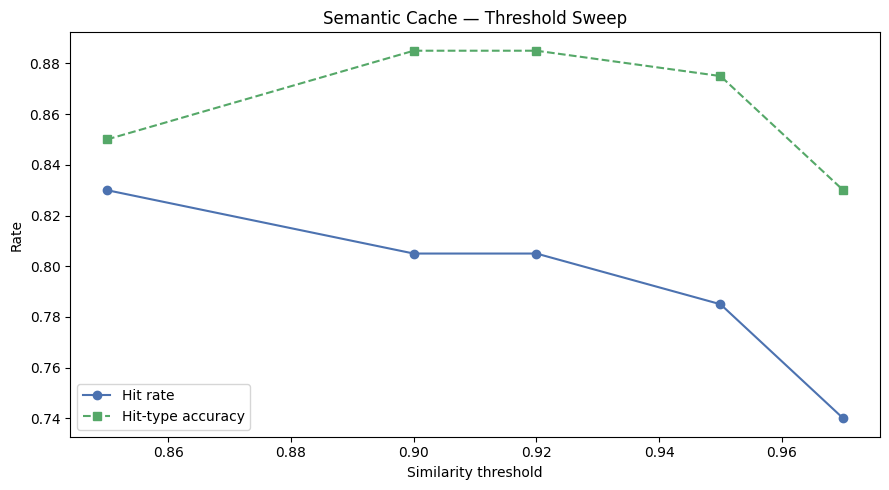

In [13]:
def light_paraphrase(q: str, rng: random.Random) -> str:
    '''Cheap, deterministic-ish perturbation approximating how a user re-types
    the same intent: light word-order shuffle + optional case change + dropped '?'.'''
    words = q.rstrip('?').split()
    if len(words) > 3:
        i = rng.randint(0, len(words) - 2)
        words[i], words[i + 1] = words[i + 1], words[i]
    out = " ".join(words)
    return out.lower() if rng.random() < 0.5 else out

rng_stream = random.Random(SEED)
base_pool = test_prompts_eval[: min(60, len(test_prompts_eval))]

stream, stream_labels, seen_pool = [], [], []
for _ in range(200):
    r = rng_stream.random()
    if seen_pool and r < 0.40:
        q = rng_stream.choice(seen_pool); label = "exact_repeat"
    elif seen_pool and r < 0.70:
        q = light_paraphrase(rng_stream.choice(seen_pool), rng_stream); label = "paraphrase"
    else:
        q = rng_stream.choice(base_pool); label = "new"; seen_pool.append(q)
    stream.append(q); stream_labels.append(label)

print(f"Query stream built: {len(stream)} queries  |  "
      f"{Counter(stream_labels)}")

# Precompute each UNIQUE query's generation once — the answer text and generation
# time don't depend on the cache threshold, only whether it's served from cache
# does, so this avoids re-running the (expensive) LLM generation for every
# threshold in the sweep.
unique_queries = list(dict.fromkeys(stream))
precomputed = {}
for q in tqdm(unique_queries, desc="Precomputing generations for cache benchmark"):
    t0 = time.time()
    ans = generate_response(q)
    precomputed[q] = (ans, time.time() - t0)

def benchmark_cache(threshold, stream, stream_labels):
    cache = SemanticCache(sim_threshold=threshold)
    correct_hit_type = 0
    for q, label in zip(stream, stream_labels):
        q_emb = embed_texts([q])
        cached, hit_type = cache.get(q, query_embedding=q_emb)
        expect_hit = label in ("exact_repeat", "paraphrase")
        got_hit = cached is not None
        if got_hit == expect_hit:
            correct_hit_type += 1
        if cached is None:
            ans, gen_time = precomputed[q]
            cache.put(q, ans, gen_time=gen_time, query_embedding=q_emb)
    return {
        "threshold": threshold,
        "hit_rate": round(cache.hit_rate(), 4),
        "time_saved_sec": round(cache.stats["time_saved_sec"], 2),
        "exact_hits": cache.stats["exact_hits"],
        "semantic_hits": cache.stats["semantic_hits"],
        "misses": cache.stats["misses"],
        "hit_type_accuracy": round(correct_hit_type / len(stream), 4),   # did hit/miss match the
                                                                          # intended repeat/paraphrase/new label?
    }

cache_sweep_results = [benchmark_cache(t, stream, stream_labels) for t in CACHE_THRESHOLD_SWEEP]
cache_sweep_df = pd.DataFrame(cache_sweep_results)
print("\nCache threshold sweep:")
print(cache_sweep_df.to_string(index=False))
cache_sweep_df.to_csv(os.path.join(PAPER_ASSETS_DIR, "cache_threshold_sweep.csv"), index=False)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(cache_sweep_df["threshold"], cache_sweep_df["hit_rate"], 'o-', color="#4C72B0", label="Hit rate")
ax1.plot(cache_sweep_df["threshold"], cache_sweep_df["hit_type_accuracy"], 's--', color="#55A868", label="Hit-type accuracy")
ax1.set_xlabel("Similarity threshold"); ax1.set_ylabel("Rate")
ax1.set_title("Semantic Cache — Threshold Sweep")
ax1.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_cache_threshold_sweep.png"), dpi=150)
plt.show()


## 23 · End-to-End: Cache → Retrieve → Fine-tuned Generation

In [14]:
# build_rag_prompt() was already defined in section 20.1 (reused there for the shared
# FT+RAG generation that feeds RAGAS-lite) — re-used here unchanged.

@torch.no_grad()
def generate_answer(query: str, max_new_tokens: int = 200, use_cache: bool = True):
    t0 = time.time()

    q_emb = embed_texts([query]) if use_cache else None
    if use_cache:
        cached_answer, hit_type = query_cache.get(query, query_embedding=q_emb)
        if cached_answer is not None:
            return {"answer": cached_answer, "cache": hit_type, "retrieved": [],
                    "latency_sec": time.time() - t0}

    retrieved = hybrid_retrieve(query) if kb_chunks else []
    prompt = build_rag_prompt(query, retrieved)
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)

    gen_t0 = time.time()
    out_ids = model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    gen_time = time.time() - gen_t0

    answer = tokenizer.decode(out_ids[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    if use_cache:
        query_cache.put(query, answer, gen_time=gen_time, query_embedding=q_emb)

    return {"answer": answer, "cache": "miss", "retrieved": retrieved, "latency_sec": time.time() - t0}

print("✅ generate_answer() ready (cache → retrieve → generate)")


✅ generate_answer() ready (cache → retrieve → generate)


### 23.1 · Smoke Test

In [15]:
test_questions_smoke = SAMPLE_QUESTIONS[:2] if "SAMPLE_QUESTIONS" in dir() else [
    "What is the last date to apply for admission at EWU?",
    "Does EWU have an internship or placement program?",
]

print("── Cold pass (cache empty) ──────────────────────────────────────────")
for q in test_questions_smoke:
    r = generate_answer(q)
    print(f"[{r['cache']:<10}] {r['latency_sec']:.2f}s  Q: {q}")
    print(f"             A: {r['answer'][:150]}")

print("\n── Warm pass (should hit cache) ─────────────────────────────────────")
for q in test_questions_smoke:
    r = generate_answer(q)
    print(f"[{r['cache']:<10}] {r['latency_sec']:.2f}s  Q: {q}")


── Cold pass (cache empty) ──────────────────────────────────────────


Chunks: 100%|██████████| 2/2 [00:00<00:00, 16.17it/s]


[miss      ] 3.39s  Q: What is the last date to apply for admission at EWU?
             A: The last date to apply for admission is August 11, 2026.


Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.96it/s]


[miss      ] 3.51s  Q: Does EWU have an internship or placement program?
             A: Yes, the Career Counseling Center runs Internship Placements and organizes Internship Fairs.

── Warm pass (should hit cache) ─────────────────────────────────────
[exact     ] 0.02s  Q: What is the last date to apply for admission at EWU?
[exact     ] 0.02s  Q: Does EWU have an internship or placement program?


## 24 · Full Ablation: Base vs Fine-tuned vs FT+RAG vs FT+RAG+Cache

All four systems are evaluated on the **same** `test_prompts_eval` items so the numbers are directly
comparable. `rag_predictions` / `rag_metrics` were already computed once in section 20.1 (shared with
RAGAS-lite) — reused here rather than re-generated, to avoid paying for the same LLM generations twice.
The cache row reuses FT+RAG's answers (cache never changes what gets generated, only whether it's served
from cache) and instead reports latency won on a cold→warm re-run.

Cold pass:   0%|          | 0/40 [00:00<?, ?it/s]


Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.22it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.05it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.66it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.43it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 10.30it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.91it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.10it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.48it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.45it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.45it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.64it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 13.30it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  7.13it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 12.02it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00,  8.92it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.83it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.72it/s]

Chunks: 100%|██████████| 2/2 [00:00<00:00, 11.65it/s]

Chunks: 1

Warm pass:   0%|          | 0/40 [00:00<?, ?it/s]


                 System  ROUGE-L  chrF++  BERTScore_F1  EWU_Domain_Hit_%  Faithfulness  Avg_Latency_s
       Base (zero-shot)   0.0089  0.0132        0.6015             47.15           NaN            NaN
        Fine-tuned (FT)   0.0654  0.0958        0.6354             62.76           NaN            NaN
               FT + RAG   0.0648  0.0924        0.6305             63.66        0.0631          9.614
FT + RAG + Cache (warm)   0.0648  0.0924        0.6305             63.66        0.0631          0.021

Cache reduces average latency by 99.8% on repeated queries (warm vs cold pass).


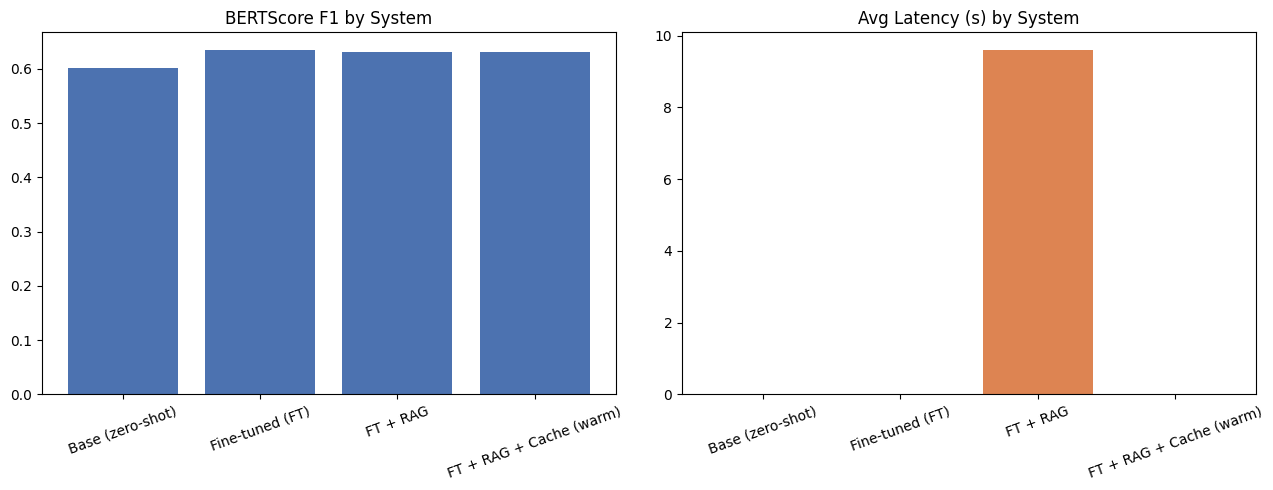

In [16]:
if kb_chunks and rag_predictions:
    # Fresh cache dedicated to this timing test: cold pass populates it, warm
    # pass re-runs the identical queries and should mostly hit.
    query_cache = SemanticCache()
    # Latency is measured on a fixed 40-query subset. In the first run the cold pass re-generated all 333 RAG
    # answers (152 min, ~27 s each) — a duplicate of §20.1 that only existed to time the cache.
    LATENCY_N = 40
    _lat_prompts = test_prompts_eval[:LATENCY_N]
    cold_latencies = [generate_answer(q, use_cache=True)["latency_sec"] for q in tqdm(_lat_prompts, desc="Cold pass")]
    warm_latencies = [generate_answer(q, use_cache=True)["latency_sec"] for q in tqdm(_lat_prompts, desc="Warm pass")]
    cache_speedup_pct = (np.mean(cold_latencies) - np.mean(warm_latencies)) / np.mean(cold_latencies) * 100

    _rag_faith = ragas_lite_metrics.get("Faithfulness")   # undefined (no retrieved context) for non-RAG rows

    ablation_table = pd.DataFrame([
        {"System": "Base (zero-shot)",        "ROUGE-L": baseline_metrics["ROUGE-L"], "chrF++": baseline_metrics["chrF++"],
         "BERTScore_F1": baseline_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": baseline_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": None, "Avg_Latency_s": None},
        {"System": "Fine-tuned (FT)",          "ROUGE-L": ft_metrics["ROUGE-L"], "chrF++": ft_metrics["chrF++"],
         "BERTScore_F1": ft_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": ft_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": None, "Avg_Latency_s": None},
        {"System": "FT + RAG",                 "ROUGE-L": rag_metrics["ROUGE-L"], "chrF++": rag_metrics["chrF++"],
         "BERTScore_F1": rag_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": rag_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": _rag_faith, "Avg_Latency_s": round(float(np.mean(cold_latencies)), 3)},
        {"System": "FT + RAG + Cache (warm)",  "ROUGE-L": rag_metrics["ROUGE-L"], "chrF++": rag_metrics["chrF++"],
         "BERTScore_F1": rag_metrics["BERTScore_F1"], "EWU_Domain_Hit_%": rag_metrics["EWU_Domain_Hit_pct"],
         "Faithfulness": _rag_faith, "Avg_Latency_s": round(float(np.mean(warm_latencies)), 3)},
    ])

    print("\n" + ablation_table.to_string(index=False))
    print(f"\nCache reduces average latency by {cache_speedup_pct:.1f}% on repeated queries (warm vs cold pass).")
    ablation_table.to_csv(os.path.join(PAPER_ASSETS_DIR, "ablation_table.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(ablation_table["System"], ablation_table["BERTScore_F1"], color="#4C72B0")
    axes[0].set_title("BERTScore F1 by System"); axes[0].tick_params(axis='x', rotation=20)
    axes[1].bar(ablation_table["System"], ablation_table["Avg_Latency_s"].fillna(0), color="#DD8452")
    axes[1].set_title("Avg Latency (s) by System"); axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_ablation.png"), dpi=150)
    plt.show()
else:
    print("Skipping full ablation — no KB/scraped chunks were loaded, so RAG arms cannot be evaluated.")


## 24.1 · Correctness, Language-Behaviour & Consistency Evaluation (ported from `rasa-eval`)

Everything above scores answers with **overlap metrics against an English reference** (ROUGE, chrF++, BERTScore, exact match). Those can't say whether an answer is *correct*, and for Bangla/Banglish answers they compare text in another language/script to an English reference. This section adds the checks from the Rasa evaluation that were missing here, run on the **same 333 items** and the **same three systems** (Base, FT, FT+RAG):

| # | Added check | Why it matters |
|---|---|---|
| A | Response-behaviour checks: empty-response %, **script/format compliance** (Bangla query → Bangla script; English/Banglish → Latin), refusal % | A multilingual bot can answer "correctly" in the wrong script/language |
| B | **LaBSE cross-lingual semantic cosine** vs. the English ground truth | mBERT-BERTScore is unreliable across English↔Bangla; LaBSE is built for it |
| C | **0–4 LLM-judge rubric** → **Strict** (=4), **Acceptable** (≥3), **Partial-or-better** (≥2) accuracy | The primary correctness measure; the notebook had none |
| D | Accuracy tables with **bootstrap 95% CIs** + paired significance (Base→FT, FT→FT+RAG) on judge score; **English-only** lexical metrics + Token-F1 | Overlap metrics are only meaningful when the reference and answer share a language |
| E | Breakdowns by **language, difficulty, category, query style, noise type, intent, ground-truth type** | Shows *where* each system fails |
| F | **Cross-language consistency** on matched triplets (same question in EN/BN/Banglish) | Tests whether the bot is equally right in all three languages |
| G | **Failure analysis** (incorrect / partial / refusal / wrong-script cases) | Error taxonomy for the paper |
| H | **Judge-vs-human validation** (quadratic-weighted κ, agreement, P/R/F1) using the human sheets from §13.1 | Makes the automatic judge defensible |
| I | Export + merge into the ablation table | Paper-ready |

**Judge design.** To avoid loading another model on the T4, the judge is the already-loaded **Qwen2.5-7B-Instruct with the LoRA adapter disabled** (`model.disable_adapter()`), i.e. the same judge model the Rasa evaluation used. It sees only the query, the verified canonical ground truth, and the response. It runs **one response at a time** and returns a score only: in the first full run, batches of 4 with left-padding left 742 of 999 outputs unparseable (only the unpadded prompt in each batch worked), and cell C2 now stops immediately if the output is unreadable instead of silently building tables from a fraction of the data.

> ⚠️ **Caveats to state in the paper.** (1) A 7B judge is a *proxy*, not ground truth — report it as an "automatic judge" and give the validation in H. (2) The judge shares weights with the zero-shot baseline generator, so it may favour baseline-style answers; the human validation is the check on this. (3) Per-category cells contain only 9 items per system (3 difficulties × 3 languages), so treat the category table as descriptive, not inferential.
>
> If you re-run only this section, first re-run §8.1 (cell "Load Category-Stratified Eval Set") once: it now also carries `Query Style`, `Noise Type`, `Intent`, `Ground Truth Type` and `Difficulty Group`. The sampling is seeded, so it selects the **same rows in the same order** and existing predictions stay aligned.


In [17]:
# ── 24.1-A · Long-form eval table + response-behaviour checks ────────────────
import gc

BANGLA_RE = re.compile(r"[\u0980-\u09FF]")

def contains_bangla(text):
    return bool(BANGLA_RE.search(str(text or "")))

def script_format_ok(language, response):
    """Bangla query -> Bangla script expected. English/Banglish -> no Bangla script."""
    response = str(response or "").strip()
    if not response:
        return False
    has_bn = contains_bangla(response)
    return has_bn if language == "bangla" else (not has_bn)

def _qid(q):
    try:
        return int(float(q))
    except Exception:
        return str(q)

DIFFICULTY_ALIAS = {"Easy": "Simple", "Medium": "Normal", "Hard": "Complex"}

# Predictions are saved to disk below so a session crash/timeout never loses them. In a FRESH session
# (predictions not in memory) they are reloaded from that file instead of being regenerated.
PRED_CSV = os.path.join(PAPER_ASSETS_DIR, "eval_predictions_saved.csv")
_live = bool(globals().get("baseline_predictions")) and bool(globals().get("ft_predictions"))
if not _live:
    _ck = {n: os.path.join(PAPER_ASSETS_DIR, f"pred_ckpt_{n}.csv") for n in ("baseline", "ft", "rag")}
    if os.path.exists(PRED_CSV):
        _saved = pd.read_csv(PRED_CSV, keep_default_na=False)
        def _load(name):
            return _saved[_saved["system"] == name].sort_values("item_idx")["bot_response"].tolist()
        baseline_predictions, ft_predictions, rag_predictions = _load("Base (zero-shot)"), _load("Fine-tuned (FT)"), _load("FT + RAG")
        print("Loaded predictions from", PRED_CSV)
    elif os.path.exists(_ck["baseline"]) and os.path.exists(_ck["ft"]):
        def _load_ck(n):
            if not os.path.exists(_ck[n]): return []
            d = pd.read_csv(_ck[n], keep_default_na=False).sort_values("idx")
            return d["response"].tolist()
        baseline_predictions, ft_predictions, rag_predictions = _load_ck("baseline"), _load_ck("ft"), _load_ck("rag")
        print("Loaded predictions from generation checkpoints:", {k: len(v) for k, v in
              zip(("baseline", "ft", "rag"), (baseline_predictions, ft_predictions, rag_predictions))})
    else:
        raise RuntimeError("No in-memory predictions and no saved files in " + PAPER_ASSETS_DIR +
                           " — run §9/§11/§20.1 first (they generate the predictions).")

SYSTEMS = {
    "Base (zero-shot)": baseline_predictions,
    "Fine-tuned (FT)":  ft_predictions,
}
if globals().get("rag_predictions"):
    SYSTEMS["FT + RAG"] = rag_predictions

# xlsx_eval_df (the 333-item eval set with Q#/Category/Difficulty/Query Style/Noise Type/
# Intent/Ground Truth Type metadata) was built in Notebook A's §8.1 from GROUND_TRUTH_XLSX,
# but only the plain lists (test_prompts_eval/test_references_eval/test_langs_eval) were
# carried over in the handoff -- not the dataframe itself. Rebuild it here from the same XLSX
# (a pure, order-independent transform -- no re-sampling/RNG involved) and align rows to the
# handed-off eval set by matching on (query, language), so the row order exactly matches
# test_prompts_eval / baseline_predictions / ft_predictions / rag_predictions.
DIFFICULTY_ALIAS = {"Easy": "Simple", "Medium": "Normal", "Hard": "Complex"}

if "xlsx_eval_df" not in globals():
    _corpus = pd.read_excel(GROUND_TRUTH_XLSX, sheet_name="Question Corpus")
    _LANGUAGE_COLUMNS = {"english": "English Query", "bangla": "Bangla Query", "banglish": "Banglish Query"}
    _xlsx_rows = []
    for _, r in _corpus.iterrows():
        qnum = r["Q#"]
        for language, qcol in _LANGUAGE_COLUMNS.items():
            query = r[qcol]
            if pd.isna(query) or not str(query).strip():
                continue
            _xlsx_rows.append({
                "Q#": qnum, "language": language, "query": str(query).strip(),
                "Category": r.get("Category", ""), "Difficulty": r.get("Difficulty", ""),
                "Difficulty Group": DIFFICULTY_ALIAS.get(str(r.get("Difficulty", "")), str(r.get("Difficulty", ""))),
                "Group": r.get("Group", ""), "Query Style": r.get("Query Style", ""),
                "Noise Type": r.get("Noise Type", ""), "Intent": r.get("Intent", ""),
                "Ground Truth Type": r.get("Ground Truth Type", ""),
                "ground_truth": str(r["Ground Truth Answer (Canonical English)"]).strip(),
            })
    _xlsx_test_df = pd.DataFrame(_xlsx_rows)

    # Match each handed-off eval item back to its metadata row by (query, language) --
    # first match wins, which is safe here since (query, language) pairs are unique per Q#.
    _lookup = {(row["query"], row["language"]): row for row in _xlsx_test_df.to_dict("records")}
    _matched_rows = []
    for q, lang, ref in zip(test_prompts_eval, test_langs_eval, test_references_eval):
        row = _lookup.get((q, lang))
        if row is None:
            raise RuntimeError(
                f"Could not find eval item in GROUND_TRUTH_XLSX for language={lang!r}: {q[:80]!r} -- "
                "check that GROUND_TRUTH_XLSX matches the file Notebook A used for this run."
            )
        if row["ground_truth"] != ref:
            raise RuntimeError(
                f"Ground truth mismatch for {q[:80]!r} -- GROUND_TRUTH_XLSX may not be the same "
                "file/version Notebook A used to build this eval set."
            )
        _matched_rows.append(row)
    xlsx_eval_df = pd.DataFrame(_matched_rows).reset_index(drop=True)
    print(f"Reconstructed xlsx_eval_df: {len(xlsx_eval_df)} rows matched to the handed-off eval set.")

meta = xlsx_eval_df.copy().reset_index(drop=True)
if "Difficulty Group" not in meta.columns:
    meta["Difficulty Group"] = meta["Difficulty"].map(DIFFICULTY_ALIAS).fillna(meta["Difficulty"])
meta["item_idx"] = np.arange(len(meta))
meta["test_id"]  = [f"{_qid(q)}_{l}" for q, l in zip(meta["Q#"], meta["language"])]

_refusal_fn = globals().get("_looks_like_refusal", lambda t: False)

frames = []
for name, preds in SYSTEMS.items():
    assert len(preds) == len(meta), f"{name}: {len(preds)} predictions vs {len(meta)} eval items — misaligned"
    d = meta.copy()
    d["system"]       = name
    d["bot_response"] = [str(p or "").strip() for p in preds]
    d["empty_response"]       = d["bot_response"].eq("")
    d["response_word_count"]  = d["bot_response"].str.split().str.len()
    d["contains_bangla_script"] = d["bot_response"].map(contains_bangla)
    d["script_format_ok"]     = [script_format_ok(l, r) for l, r in zip(d["language"], d["bot_response"])]
    d["is_refusal"]           = [bool(_refusal_fn(r)) for r in d["bot_response"]]
    frames.append(d)

eval_long = pd.concat(frames, ignore_index=True)
eval_long[["system", "item_idx", "test_id", "bot_response"]].to_csv(
    PRED_CSV, index=False, encoding="utf-8-sig")            # <- crash-proof copy of every prediction
print("Predictions saved →", PRED_CSV)
print(f"eval_long: {len(eval_long)} rows = {len(meta)} items × {len(SYSTEMS)} systems  ({list(SYSTEMS)})")

behaviour = (
    eval_long.groupby(["system", "language"], sort=False)
    .agg(N=("test_id", "count"),
         Empty_pct=("empty_response", lambda s: 100 * s.mean()),
         Script_Format_OK_pct=("script_format_ok", lambda s: 100 * s.mean()),
         Refusal_pct=("is_refusal", lambda s: 100 * s.mean()),
         Mean_Words=("response_word_count", "mean"))
    .round(2).reset_index()
)
print("\nResponse-behaviour checks (language/script compliance, empties, refusals):")
print(behaviour.to_string(index=False))

Reconstructed xlsx_eval_df: 333 rows matched to the handed-off eval set.
Predictions saved → /kaggle/working/paper_assets/eval_predictions_saved.csv
eval_long: 999 rows = 333 items × 3 systems  (['Base (zero-shot)', 'Fine-tuned (FT)', 'FT + RAG'])

Response-behaviour checks (language/script compliance, empties, refusals):
          system language   N  Empty_pct  Script_Format_OK_pct  Refusal_pct  Mean_Words
Base (zero-shot)   bangla 111        0.0                 100.0          0.0       28.70
Base (zero-shot)  english 111        0.0                   0.9          0.0       31.86
Base (zero-shot) banglish 111        0.0                   0.0          0.0       30.29
 Fine-tuned (FT)   bangla 111        0.0                 100.0          0.0       19.84
 Fine-tuned (FT)  english 111        0.0                 100.0          0.0       21.35
 Fine-tuned (FT) banglish 111        0.0                 100.0          0.0       22.05
        FT + RAG   bangla 111        0.0                 100

In [18]:
# ── 24.1-B · LaBSE cross-lingual semantic similarity vs English ground truth ─
# Supporting evidence, NOT the definition of correctness. If it fails, the rest of 24.1 still runs.
eval_long["Semantic_Cosine"] = np.nan

try:
    from sentence_transformers import SentenceTransformer

    free_gb = (torch.cuda.mem_get_info()[0] / 1e9) if torch.cuda.is_available() else 0.0
    labse_device = "cuda" if free_gb > 4.0 else "cpu"      # T4 is already crowded (Qwen + BGE-M3 + reranker)
    print(f"Loading LaBSE on {labse_device} (free VRAM ≈ {free_gb:.1f} GB)...")
    labse = SentenceTransformer("sentence-transformers/LaBSE", device=labse_device)

    ok = ~eval_long["empty_response"]
    resp_texts = eval_long.loc[ok, "bot_response"].tolist()
    uniq_gt    = eval_long["ground_truth"].drop_duplicates().tolist()   # each GT is reused across languages/systems
    gt_index   = {g: i for i, g in enumerate(uniq_gt)}

    resp_emb = labse.encode(resp_texts, batch_size=32, normalize_embeddings=True,
                            convert_to_numpy=True, show_progress_bar=True)
    gt_emb   = labse.encode(uniq_gt, batch_size=32, normalize_embeddings=True,
                            convert_to_numpy=True, show_progress_bar=True)

    gt_rows = np.array([gt_index[g] for g in eval_long.loc[ok, "ground_truth"]])
    eval_long.loc[ok, "Semantic_Cosine"] = np.sum(resp_emb * gt_emb[gt_rows], axis=1)   # unit vectors -> dot = cosine

    del labse, resp_emb, gt_emb
    print("✅ LaBSE semantic evaluation complete.")
    print(eval_long.groupby(["system", "language"], sort=False)["Semantic_Cosine"]
          .agg(["count", "mean", "median", "std"]).round(4))
except Exception as e:
    print("⚠️ LaBSE skipped:", type(e).__name__, str(e))
    print("Semantic_Cosine stays NaN; the judge-based accuracy below is unaffected.")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading LaBSE on cuda (free VRAM ≈ 8.4 GB)...


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ LaBSE semantic evaluation complete.
                           count    mean  median     std
system           language                               
Base (zero-shot) bangla      111  0.4652  0.4583  0.1042
                 english     111  0.4496  0.4546  0.1114
                 banglish    111  0.4256  0.4365  0.0828
Fine-tuned (FT)  bangla      111  0.4144  0.4197  0.0943
                 english     111  0.4221  0.4319  0.1304
                 banglish    111  0.3562  0.3785  0.1317
FT + RAG         bangla      111  0.4112  0.4120  0.0990
                 english     111  0.4120  0.4331  0.1440
                 banglish    111  0.3364  0.3525  0.1616


In [19]:
# ── 24.1-C1 · Judge rubric, prompt and parser ────────────────────────────────
JUDGE_SYSTEM = """You are evaluating a university information chatbot.

Use ONLY the provided canonical ground-truth answer as the factual authority.
Do not use outside knowledge.

The user query and chatbot response may be English, Bengali (Bangla),
or Banglish (Bengali written using Latin letters). Compare the meaning
of the response with the English canonical ground truth.

Rubric:
4 = Fully correct and sufficiently answers the query. No material contradiction.
3 = Core answer is correct; minor omission or harmless extra detail only.
2 = Partially correct but misses an important fact/condition or is materially incomplete.
1 = Mostly incorrect, misleading, or only tangentially relevant.
0 = Incorrect, contradictory, unrelated, or no meaningful answer.

Return ONLY valid JSON in this form (no explanation):
{"score": 4, "label": "fully_correct"}

Allowed labels:
fully_correct, mostly_correct, partially_correct, mostly_incorrect, incorrect
"""

JUDGE_PREFILL = '{"score":'   # the answer is pre-started so the model can only continue with the score
JUDGE_CHAR_CAP = 1200   # cap each field so the prompt never needs token truncation (which would cut the instructions)

def build_judge_prompt(row):
    user = (
        f"LANGUAGE: {row['language']}\n"
        f"USER QUERY:\n{str(row['query'])[:JUDGE_CHAR_CAP]}\n\n"
        f"CANONICAL GROUND TRUTH:\n{str(row['ground_truth'])[:JUDGE_CHAR_CAP]}\n\n"
        f"CHATBOT RESPONSE:\n{str(row['bot_response'])[:JUDGE_CHAR_CAP]}\n\n"
        "Judge correctness and completeness."
    )
    return (f"<|im_start|>system\n{JUDGE_SYSTEM}<|im_end|>\n"
            f"<|im_start|>user\n{user}<|im_end|>\n"
            f"<|im_start|>assistant\n{JUDGE_PREFILL}")

_JUDGE_LABELS = {0: "incorrect", 1: "mostly_incorrect", 2: "partially_correct",
                 3: "mostly_correct", 4: "fully_correct"}

def parse_judge(text):
    text = str(text).strip()
    m = re.search(r"\{.*?\}", text, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group(0))
            score = int(obj["score"])
            if score in {0, 1, 2, 3, 4}:
                return score, str(obj.get("label", "")), str(obj.get("reason", "")), text
        except Exception:
            pass
    m = re.search(r'"?score"?\s*[:=]\s*([0-4])', text)
    if m:
        score = int(m.group(1))
        return score, _JUDGE_LABELS[score], "Parser fallback", text
    return np.nan, "parse_error", "Could not parse judge output", text

print("Judge rubric/prompt/parser defined.")

Judge rubric/prompt/parser defined.


In [20]:
# ── 24.1-C2 · Run / resume the local 0–4 correctness judge ───────────────────
# Reuses the already-loaded `model` with the LoRA adapter DISABLED => plain Qwen2.5-7B-Instruct.
# Greedy decoding => deterministic. Checkpointed: safe to re-run after a crash.
#
# WHY BATCH SIZE 1: in the first full run, batches of 4 with left-padding produced unparseable output for
# 742 / 999 responses (≈ 3 of every 4: only the longest, unpadded prompt in each batch was readable).
# Single sequences need no padding, so that failure mode cannot occur. The answer is also score-only and
# pre-started with '{"score":' (a "reason" written AFTER the score cannot change the score, it only costs time).
JUDGE_BATCH_SIZE      = 1
JUDGE_MAX_NEW_TOKENS  = 32
JUDGE_CANARY_N        = 8       # judge this many first and abort immediately if the output is unreadable
JUDGE_MAX_PARSE_ERROR = 0.05    # abort (before any tables are built) if more than 5% cannot be parsed
JUDGE_CKPT = os.path.join(PAPER_ASSETS_DIR, "local_judge_checkpoint.csv")

import hashlib
# Key includes a hash of the response text: if predictions are ever regenerated (sampling differs), the
# stale judgement is NOT reused for a different answer — it is simply re-judged.
eval_long["_key"] = (eval_long["system"] + "||" + eval_long["item_idx"].astype(str) + "||" +
                     eval_long["bot_response"].map(lambda t: hashlib.md5(t.encode("utf-8")).hexdigest()[:10]))

if os.path.exists(JUDGE_CKPT):
    old = pd.read_csv(JUDGE_CKPT)
    old = old[old["judge_score"].notna()]          # unparsed rows are re-judged, never trusted
    print("Loaded judge checkpoint rows:", len(old))
else:
    old = pd.DataFrame(columns=["_key", "judge_score", "judge_label", "judge_reason", "judge_raw"])

done_keys = set(old["_key"].astype(str))
pending   = eval_long[~eval_long["_key"].isin(done_keys)]

new_rows, to_model = [], []
for _, r in pending.iterrows():
    if r["empty_response"]:
        new_rows.append({"_key": r["_key"], "judge_score": 0, "judge_label": "incorrect",
                         "judge_reason": "No usable chatbot response.", "judge_raw": ""})
    else:
        to_model.append(r)
print(f"Auto-scored 0 (empty): {len(new_rows)}   |   Need model judging: {len(to_model)}")

def _judge_generate(row):
    enc = tokenizer(build_judge_prompt(row), return_tensors="pt").to(model.device)   # ONE sequence: no padding
    with torch.inference_mode(), model.disable_adapter():
        out = model.generate(
            **enc, max_new_tokens=JUDGE_MAX_NEW_TOKENS, do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.convert_tokens_to_ids("<|im_end|>"),
        )
    return tokenizer.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True)

def _save_ckpt():
    pd.concat([old, pd.DataFrame(new_rows)], ignore_index=True) \
      .drop_duplicates("_key", keep="last").to_csv(JUDGE_CKPT, index=False, encoding="utf-8-sig")

if to_model:                              # only touch the GPU model if something actually needs judging
    _prev_cache = model.config.use_cache
    model.config.use_cache = True
    model.eval()
    judged_now = []
    try:
        for n, r in enumerate(tqdm(to_model, desc="Correctness judging")):
            raw = JUDGE_PREFILL + _judge_generate(r)
            score, label, reason, raw_full = parse_judge(raw)
            rec = {"_key": r["_key"], "judge_score": score, "judge_label": label,
                   "judge_reason": "" if reason == "Parser fallback" else reason, "judge_raw": raw_full}
            new_rows.append(rec); judged_now.append(rec)

            if n + 1 == JUDGE_CANARY_N:                       # fail fast, not after 45 minutes
                bad = [x for x in judged_now if pd.isna(x["judge_score"])]
                if len(bad) > JUDGE_CANARY_N // 4:
                    _save_ckpt()
                    raise RuntimeError(
                        f"Judge canary failed: {len(bad)}/{JUDGE_CANARY_N} outputs unparseable. Raw samples:\n" +
                        "\n".join(repr(x["judge_raw"][:200]) for x in bad[:3]) +
                        "\nSee the note at the top of this cell; do not continue to 24.1-D.")
            if (n + 1) % 25 == 0:
                _save_ckpt()
    finally:
        model.config.use_cache = _prev_cache
        _save_ckpt()
else:
    print("Nothing pending — all judgements come from the checkpoint (no GPU model needed).")

judge_results = pd.concat([old, pd.DataFrame(new_rows)], ignore_index=True).drop_duplicates("_key", keep="last")

for c in ["judge_score", "judge_label", "judge_reason", "judge_raw"]:
    if c in eval_long.columns:
        eval_long = eval_long.drop(columns=c)
eval_long = eval_long.merge(judge_results, on="_key", how="left")

js = eval_long["judge_score"]
eval_long["Strict_Correct"]     = np.where(js.notna(), (js == 4).astype(float), np.nan)   # score == 4
eval_long["Acceptable_Correct"] = np.where(js.notna(), (js >= 3).astype(float), np.nan)   # score >= 3
eval_long["Partial_or_Better"]  = np.where(js.notna(), (js >= 2).astype(float), np.nan)   # score >= 2

n_err = int(js.isna().sum())
err_rate = n_err / len(eval_long)
print(f"\nJudge parse errors: {n_err} / {len(eval_long)}  ({100*err_rate:.1f}%)")
print("\nJudge score distribution per system:")
print(pd.crosstab(eval_long["system"], eval_long["judge_score"]))

# HARD GATE: results built on a mostly-unparsed judge are worse than no results (the first run silently
# produced "accuracy" figures from only 257 of 999 items). Stop here instead of building tables.
if err_rate > JUDGE_MAX_PARSE_ERROR:
    _bad = eval_long[js.isna()]["judge_raw"].dropna().head(3).tolist()
    raise RuntimeError(f"{100*err_rate:.1f}% of judge outputs could not be parsed (limit {100*JUDGE_MAX_PARSE_ERROR:.0f}%). "
                       f"Raw samples: {[t[:160] for t in _bad]}. Do not run 24.1-D..I on this.")

Auto-scored 0 (empty): 0   |   Need model judging: 999


Correctness judging:   0%|          | 0/999 [00:00<?, ?it/s]


Judge parse errors: 0 / 999  (0.0%)

Judge score distribution per system:
judge_score        0   1    2    3  4
system                               
Base (zero-shot)  29  18  189   95  2
FT + RAG          52  53  142   86  0
Fine-tuned (FT)   40  50  142  100  1


In [21]:
# ── 24.1-D · Accuracy with bootstrap CIs, paired significance, English-only lexical ─
import unicodedata
def _boot(values):
    x = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    return bootstrap_ci(x)          # defined in §8: (mean, lo, hi), N_BOOTSTRAP resamples

def _pct(s):
    x = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(x) == 0 else 100 * x.mean()

LANGS = ["english", "bangla", "banglish"]

rows = []
for system, g in eval_long.groupby("system", sort=False):
    for scope, gg in [("Overall", g)] + [(l, g[g["language"] == l]) for l in LANGS]:
        row = {"System": system, "Scope": scope, "N": len(gg)}
        for col, lab in [("Strict_Correct", "Strict_Acc"),
                         ("Acceptable_Correct", "Acceptable_Acc"),
                         ("Partial_or_Better", "Partial_or_Better")]:
            m, lo, hi = _boot(gg[col])
            row[f"{lab}_pct"]  = round(100 * m, 2)
            row[f"{lab}_CI95"] = f"[{100*lo:.1f}, {100*hi:.1f}]"
        row["Mean_Judge_Score"]     = round(gg["judge_score"].mean(), 3)
        row["Mean_Semantic_Cosine"] = round(gg["Semantic_Cosine"].mean(), 4)
        row["Script_Format_OK_pct"] = round(_pct(gg["script_format_ok"]), 2)
        row["Empty_pct"]            = round(_pct(gg["empty_response"]), 2)
        row["Refusal_pct"]          = round(_pct(gg["is_refusal"]), 2)
        rows.append(row)

accuracy_table = pd.DataFrame(rows)
print("HEADLINE ACCURACY (judge-based, bootstrap 95% CI)\n")
print(accuracy_table[["System", "Scope", "N", "Strict_Acc_pct", "Strict_Acc_CI95",
                      "Acceptable_Acc_pct", "Acceptable_Acc_CI95",
                      "Mean_Judge_Score", "Mean_Semantic_Cosine",
                      "Script_Format_OK_pct"]].to_string(index=False))

# ── Paired significance on the SAME items ────────────────────────────────────
sig_rows = []
for a, b in [("Base (zero-shot)", "Fine-tuned (FT)"), ("Fine-tuned (FT)", "FT + RAG")]:
    if a not in SYSTEMS or b not in SYSTEMS:
        continue
    A = eval_long[eval_long["system"] == a].set_index("item_idx")
    B = eval_long[eval_long["system"] == b].set_index("item_idx")
    idx = A.index.intersection(B.index)
    idx = [i for i in idx if pd.notna(A.at[i, "judge_score"]) and pd.notna(B.at[i, "judge_score"])]
    for col, label in [("judge_score", "Mean judge score (0-4)"), ("Acceptable_Correct", "Acceptable accuracy")]:
        av, bv = A.loc[idx, col].astype(float).values, B.loc[idx, col].astype(float).values
        diff, p_boot = paired_bootstrap_p(av, bv)
        try:
            p_w = float(wilcoxon(av, bv).pvalue)
        except ValueError:                      # all paired differences are zero
            p_w = float("nan")
        sig_rows.append({"comparison": f"{a}  →  {b}", "metric": label, "n_pairs": len(idx),
                         "mean_A": round(av.mean(), 4), "mean_B": round(bv.mean(), 4),
                         "delta": round(diff, 4), "p_bootstrap": round(p_boot, 4),
                         "p_wilcoxon": None if np.isnan(p_w) else round(p_w, 4),
                         "significant_at_0.05": bool(p_boot < 0.05)})
significance_judge = pd.DataFrame(sig_rows)
print("\nPAIRED SIGNIFICANCE (judge-based)\n")
print(significance_judge.to_string(index=False) if len(significance_judge) else "n/a")

# ── English-only lexical metrics (surface overlap is only meaningful when reference & answer share a language) ─
def _norm_en(t):
    t = unicodedata.normalize("NFKC", str(t or "")).lower()
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", t)).strip()

def token_f1(pred, ref):
    p, r = _norm_en(pred).split(), _norm_en(ref).split()
    if not p and not r: return 1.0
    if not p or not r:  return 0.0
    ov = sum((Counter(p) & Counter(r)).values())
    if ov == 0: return 0.0
    pr, rc = ov / len(p), ov / len(r)
    return 2 * pr * rc / (pr + rc)

from rouge_score import rouge_scorer
import sacrebleu
_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
_chrf  = sacrebleu.CHRF(word_order=2)          # chrF++
en_sel = [i for i, l in enumerate(meta["language"]) if l == "english"]
en_refs = meta["ground_truth"].tolist()
en_rows = []
for system, preds in SYSTEMS.items():
    en_rows.append({
        "System": system, "N_english": len(en_sel),
        "ROUGE-L":  round(float(np.mean([_rouge.score(en_refs[i], preds[i])["rougeL"].fmeasure for i in en_sel])), 4),
        "chrF++":   round(float(np.mean([_chrf.sentence_score(preds[i], [en_refs[i]]).score / 100 for i in en_sel])), 4),
        "Token_F1": round(float(np.mean([token_f1(preds[i], en_refs[i]) for i in en_sel])), 4),
        "Exact_Match_%": round(100 * float(np.mean([_norm_en(preds[i]) == _norm_en(en_refs[i]) for i in en_sel])), 2),
    })
english_lexical_table = pd.DataFrame(en_rows)
print("\nENGLISH-ONLY LEXICAL METRICS (report these instead of all-language ROUGE/chrF++)\n")
print(english_lexical_table.to_string(index=False))

HEADLINE ACCURACY (judge-based, bootstrap 95% CI)

          System    Scope   N  Strict_Acc_pct Strict_Acc_CI95  Acceptable_Acc_pct Acceptable_Acc_CI95  Mean_Judge_Score  Mean_Semantic_Cosine  Script_Format_OK_pct
Base (zero-shot)  Overall 333             0.6      [0.0, 1.5]               29.13        [24.6, 34.2]             2.069                0.4468                 33.63
Base (zero-shot)  english 111             0.9      [0.0, 2.7]                8.11         [3.6, 13.5]             1.613                0.4496                  0.90
Base (zero-shot)   bangla 111             0.0      [0.0, 0.0]               28.83        [20.7, 37.8]             2.126                0.4652                100.00
Base (zero-shot) banglish 111             0.9      [0.0, 2.7]               50.45        [41.4, 59.5]             2.468                0.4256                  0.00
 Fine-tuned (FT)  Overall 333             0.3      [0.0, 1.2]               30.33        [25.5, 35.4]             1.916          


BY LANGUAGE  (Acceptable accuracy %, N per cell in the saved CSV)
system    Base (zero-shot)  FT + RAG  Fine-tuned (FT)
language                                             
bangla                28.8      10.8              8.1
banglish              50.4      15.3             20.7
english                8.1      51.4             62.2

BY DIFFICULTY  (Acceptable accuracy %, N per cell in the saved CSV)
system            Base (zero-shot)  FT + RAG  Fine-tuned (FT)
Difficulty Group                                             
Complex                       36.0      24.3             34.2
Normal                        38.7      20.7             25.2
Simple                        12.6      32.4             31.5

WEAKEST 10 CATEGORIES — Fine-tuned (n=9 items each: descriptive only)
                                             Category  N  Acceptable_Acc_pct Mean_Judge_Score
                                University Governance  9               0.000         0.666667
                         

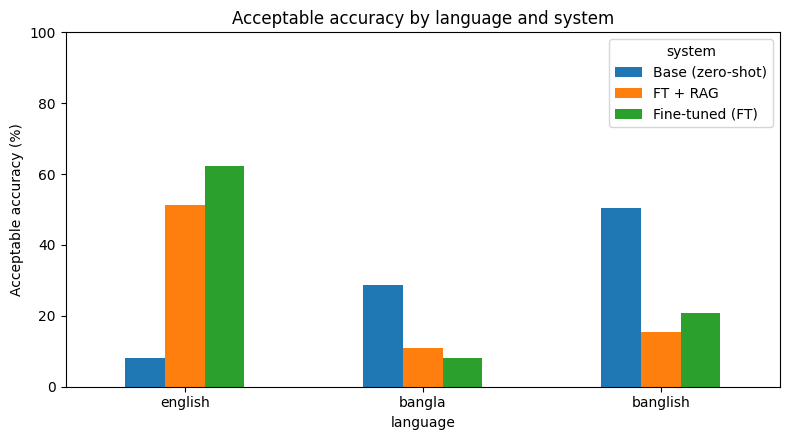

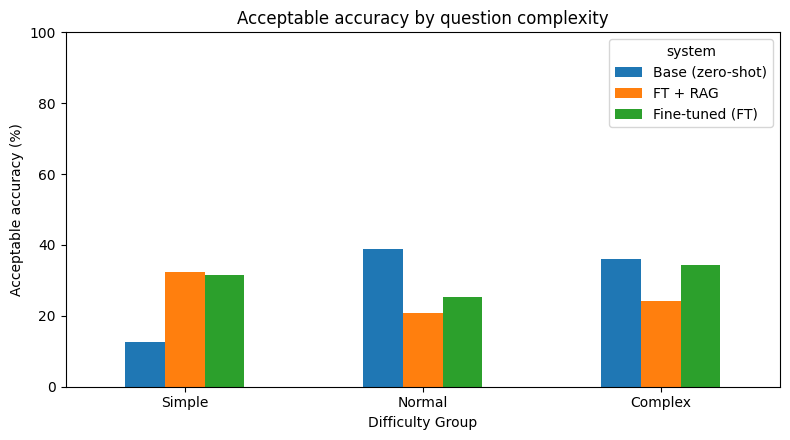

In [22]:
# ── 24.1-E · Breakdowns: language / difficulty / category / style / noise / intent / GT type ─
def summarize(df, groups):
    return (
        df.groupby(groups, dropna=False, sort=False)
        .agg(N=("test_id", "count"),
             Strict_Acc_pct=("Strict_Correct", _pct),
             Acceptable_Acc_pct=("Acceptable_Correct", _pct),
             Partial_or_Better_pct=("Partial_or_Better", _pct),
             Mean_Judge_Score=("judge_score", "mean"),
             Mean_Semantic_Cosine=("Semantic_Cosine", "mean"),
             Script_Format_OK_pct=("script_format_ok", _pct),
             Empty_pct=("empty_response", _pct))
        .reset_index().round(3)
    )

BREAKDOWN_DIMS = {
    "By Language":          ["language"],
    "By Difficulty":        ["Difficulty Group"],
    "Difficulty x Language": ["Difficulty Group", "language"],
    "By Category":          ["Category"],
    "Category x Language":  ["Category", "language"],
    "By Query Style":       ["Query Style"],
    "By Noise Type":        ["Noise Type"],
    "By Intent":            ["Intent"],
    "By GT Type":           ["Ground Truth Type"],
}

breakdowns = {}
for name, dims in BREAKDOWN_DIMS.items():
    if all(d in eval_long.columns for d in dims):
        breakdowns[name] = summarize(eval_long, ["system"] + dims)
    else:
        print(f"(skipped '{name}': column(s) {dims} not in eval set — re-run §8.1 with the patched cell)")

for name in ["By Language", "By Difficulty"]:
    if name in breakdowns:
        print(f"\n{name.upper()}  (Acceptable accuracy %, N per cell in the saved CSV)")
        dim = BREAKDOWN_DIMS[name][0]
        print(breakdowns[name].pivot(index=dim, columns="system", values="Acceptable_Acc_pct").round(1))

if "By Category" in breakdowns and "Fine-tuned (FT)" in SYSTEMS:
    cat_ft = breakdowns["By Category"].query("system == 'Fine-tuned (FT)'").sort_values("Acceptable_Acc_pct")
    print("\nWEAKEST 10 CATEGORIES — Fine-tuned (n=9 items each: descriptive only)")
    print(cat_ft[["Category", "N", "Acceptable_Acc_pct", "Mean_Judge_Score"]].head(10).to_string(index=False))

# ── Figures ──────────────────────────────────────────────────────────────────
if "By Language" in breakdowns:
    piv = breakdowns["By Language"].pivot(index="language", columns="system", values="Acceptable_Acc_pct").reindex(LANGS)
    ax = piv.plot(kind="bar", figsize=(8, 4.5), rot=0)
    ax.set_ylim(0, 100); ax.set_ylabel("Acceptable accuracy (%)"); ax.set_title("Acceptable accuracy by language and system")
    plt.tight_layout(); plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_accuracy_by_language.png"), dpi=200); plt.show()

if "By Difficulty" in breakdowns:
    piv = (breakdowns["By Difficulty"].pivot(index="Difficulty Group", columns="system", values="Acceptable_Acc_pct")
           .reindex(["Simple", "Normal", "Complex"]))
    ax = piv.plot(kind="bar", figsize=(8, 4.5), rot=0)
    ax.set_ylim(0, 100); ax.set_ylabel("Acceptable accuracy (%)"); ax.set_title("Acceptable accuracy by question complexity")
    plt.tight_layout(); plt.savefig(os.path.join(PAPER_ASSETS_DIR, "fig_accuracy_by_difficulty.png"), dpi=200); plt.show()

In [23]:
# ── 24.1-F · Cross-language consistency on matched EN / BN / Banglish triplets ─
cons_rows, triplets_by_system = [], {}
for system, g in eval_long.groupby("system", sort=False):
    t = g.pivot_table(index="Q#", columns="language", values="judge_score", aggfunc="first")
    for l in LANGS:
        if l not in t.columns:
            t[l] = np.nan
    t = t[LANGS].dropna()                      # complete triplets only (parse errors dropped)
    t["All_3_Acceptable"] = (t[LANGS] >= 3).all(axis=1)
    t["All_3_Strict"]     = (t[LANGS] == 4).all(axis=1)
    t["Min_Language_Score"] = t[LANGS].min(axis=1)
    t["Cross_Language_SD"]  = t[LANGS].std(axis=1)
    triplets_by_system[system] = t.reset_index()
    cons_rows.append({
        "System": system, "N_triplets": len(t),
        "All_3_Acceptable_%": round(100 * t["All_3_Acceptable"].mean(), 2),
        "All_3_Strict_%":     round(100 * t["All_3_Strict"].mean(), 2),
        "Mean_Min_Language_Score": round(t["Min_Language_Score"].mean(), 3),
        "Mean_Cross_Language_SD":  round(t["Cross_Language_SD"].mean(), 3),
        "Gap_EN_minus_BN":       round((t["english"] - t["bangla"]).mean(), 3),
        "Gap_EN_minus_Banglish": round((t["english"] - t["banglish"]).mean(), 3),
    })

consistency_table = pd.DataFrame(cons_rows)
print("CROSS-LANGUAGE CONSISTENCY  (Gap > 0 => English scores higher than that language)\n")
print(consistency_table.to_string(index=False))

CROSS-LANGUAGE CONSISTENCY  (Gap > 0 => English scores higher than that language)

          System  N_triplets  All_3_Acceptable_%  All_3_Strict_%  Mean_Min_Language_Score  Mean_Cross_Language_SD  Gap_EN_minus_BN  Gap_EN_minus_Banglish
Base (zero-shot)         111                 1.8             0.0                    1.441                   0.662           -0.514                 -0.856
 Fine-tuned (FT)         111                 1.8             0.0                    1.135                   0.839            1.036                  0.622
        FT + RAG         111                 3.6             0.0                    1.018                   0.842            0.847                  0.631


In [24]:
# ── 24.1-G · Failure analysis ────────────────────────────────────────────────
failure_summary = []
for system, g in eval_long.groupby("system", sort=False):
    wrong   = g[g["judge_score"] <= 1]
    partial = g[g["judge_score"] == 2]
    failure_summary.append({
        "System": system, "N": len(g),
        "Incorrect (score 0-1)": len(wrong),
        "Partial (score 2)": len(partial),
        "Wrong-script responses": int((~g["script_format_ok"]).sum()),
        "Refusals": int(g["is_refusal"].sum()),
        "Refusals that were also judged wrong": int(((g["judge_score"] <= 1) & g["is_refusal"]).sum()),
        "Empty responses": int(g["empty_response"].sum()),
    })
failure_summary = pd.DataFrame(failure_summary)
print(failure_summary.to_string(index=False))

_case_cols = ["system", "test_id", "language", "Category", "Difficulty", "query", "ground_truth",
              "bot_response", "judge_score", "judge_label", "judge_reason", "Semantic_Cosine"]
_case_cols = [c for c in _case_cols if c in eval_long.columns]
incorrect_cases = eval_long[eval_long["judge_score"] <= 1][_case_cols].copy()
partial_cases   = eval_long[eval_long["judge_score"] == 2][_case_cols].copy()
wrong_script_cases = eval_long[~eval_long["script_format_ok"]][_case_cols].copy()

if "Fine-tuned (FT)" in SYSTEMS:
    print("\nFive lowest-scoring Fine-tuned answers (full text in the exported workbook):")
    show = incorrect_cases.query("system == 'Fine-tuned (FT)'").head(5)
    for _, r in show.iterrows():
        print(f"\n[{r['language']}] {r['query'][:120]}\n  judge={int(r['judge_score'])}  {r['judge_reason'][:160]}")

          System   N  Incorrect (score 0-1)  Partial (score 2)  Wrong-script responses  Refusals  Refusals that were also judged wrong  Empty responses
Base (zero-shot) 333                     47                189                     221         0                                     0                0
 Fine-tuned (FT) 333                     90                142                       0         0                                     0                0
        FT + RAG 333                    105                142                       0         0                                     0                0

Five lowest-scoring Fine-tuned answers (full text in the exported workbook):

[bangla] একজন শিক্ষার্থী কিস্তিতে পরিশোধের সুবিধা কীভাবে ব্যবহার করবে, অনুসরণ করবে বা সামলাবে?
  judge=1  

[english] What should I do if I have a problem with deans and department chairs and the normal process is not working?
  judge=0  

[banglish] amar bachelor different discipline e hole ba CGPA preferred le

In [25]:
# ── 24.1-H · Validate the automatic judge against the human annotators from §13.1 ─
# Uses the SAME annotator sheets (`human_eval_annotator*_FILLED.csv`), reading their `correctness_1to5`
# column and mapping it to the judge's 0-4 scale (human - 1). Sheets are blind to the judge, which avoids
# anchoring annotators on the automatic score.
def validate_judge_against_humans(system="Fine-tuned (FT)", min_rows=20):
    from scipy.stats import spearmanr
    from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support

    paths = sorted(glob.glob(os.path.join(PAPER_ASSETS_DIR, "human_eval_annotator*_FILLED.csv")))
    if not paths:
        print("No *_FILLED.csv annotation sheets found in paper_assets/ — skipping (run §13.1 annotation first).")
        return None

    j = eval_long[eval_long["system"] == system][["item_idx", "judge_score"]].dropna()
    out = []
    for p in paths:
        h = pd.read_csv(p)
        h["human_0_4"] = pd.to_numeric(h["correctness_1to5"], errors="coerce") - 1
        m = h[["item_id", "human_0_4"]].dropna().merge(j, left_on="item_id", right_on="item_idx")
        if len(m) < min_rows:
            print(f"{os.path.basename(p)}: only {len(m)} scored rows (< {min_rows}) — skipped.")
            continue
        hh = m["human_0_4"].round().astype(int).clip(0, 4)
        jj = m["judge_score"].astype(int)
        hb, jb = (hh >= 3).astype(int), (jj >= 3).astype(int)      # Acceptable vs not
        pr, rc, f1, _ = precision_recall_fscore_support(hb, jb, average="binary", zero_division=0)
        out.append({
            "annotator_file": os.path.basename(p), "N": len(m),
            "Exact_0-4_agreement": round(float((hh == jj).mean()), 3),
            "Quadratic_weighted_kappa": round(float(cohen_kappa_score(hh, jj, weights="quadratic")), 3),
            "Spearman_rho": round(float(spearmanr(hh, jj).correlation), 3),
            "Acceptable_agreement": round(float((hb == jb).mean()), 3),
            "Acceptable_precision": round(float(pr), 3),
            "Acceptable_recall": round(float(rc), 3),
            "Acceptable_F1": round(float(f1), 3),
        })
    return pd.DataFrame(out) if out else None

judge_validation = validate_judge_against_humans()
if judge_validation is not None:
    print(judge_validation.to_string(index=False))
    print("\nRule of thumb for the paper: quadratic-weighted κ ≥ 0.60 = substantial agreement (Landis & Koch 1977).")
    print("With ~50 items the κ interval is wide — raise N_HUMAN_EVAL_SAMPLES in §13.1 (≈150) for a tighter estimate.")
else:
    judge_validation = pd.DataFrame()

No *_FILLED.csv annotation sheets found in paper_assets/ — skipping (run §13.1 annotation first).


In [26]:
# ── 24.1-I · Export + merge correctness columns into the ablation table ──────
out_dir = PAPER_ASSETS_DIR

eval_long.drop(columns=["_key"], errors="ignore").to_csv(
    os.path.join(out_dir, "eval_long_with_judge.csv"), index=False, encoding="utf-8-sig")
accuracy_table.to_csv(os.path.join(out_dir, "accuracy_table_with_ci.csv"), index=False)
significance_judge.to_csv(os.path.join(out_dir, "judge_significance.csv"), index=False)
english_lexical_table.to_csv(os.path.join(out_dir, "english_only_lexical_metrics.csv"), index=False)
consistency_table.to_csv(os.path.join(out_dir, "cross_language_consistency.csv"), index=False)

# Ablation table + correctness columns (the cache row reuses FT+RAG answers, so it inherits FT+RAG correctness)
if "ablation_table" in globals():
    _ov = accuracy_table[accuracy_table["Scope"] == "Overall"].set_index("System")
    _cols = ["Strict_Acc_pct", "Acceptable_Acc_pct", "Mean_Judge_Score", "Mean_Semantic_Cosine", "Script_Format_OK_pct"]
    def _lookup(system_name):
        key = "FT + RAG" if str(system_name).startswith("FT + RAG") else system_name
        return _ov.loc[key, _cols] if key in _ov.index else pd.Series({c: np.nan for c in _cols})
    ablation_with_correctness = pd.concat(
        [ablation_table, ablation_table["System"].apply(_lookup)], axis=1)
    ablation_with_correctness.to_csv(os.path.join(out_dir, "ablation_table_with_correctness.csv"), index=False)
    print("Ablation table with correctness columns:\n")
    print(ablation_with_correctness.to_string(index=False))

xlsx_path = os.path.join(out_dir, "correctness_report.xlsx")
try:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
        accuracy_table.to_excel(w, sheet_name="Accuracy (CI)", index=False)
        significance_judge.to_excel(w, sheet_name="Significance", index=False)
        english_lexical_table.to_excel(w, sheet_name="English lexical", index=False)
        behaviour.to_excel(w, sheet_name="Behaviour", index=False)
        for name, df in breakdowns.items():
            df.to_excel(w, sheet_name=name[:31], index=False)
        consistency_table.to_excel(w, sheet_name="Consistency", index=False)
        for system, t in triplets_by_system.items():
            t.to_excel(w, sheet_name=f"Triplets {system.split()[0]}"[:31], index=False)
        failure_summary.to_excel(w, sheet_name="Failure summary", index=False)
        incorrect_cases.to_excel(w, sheet_name="Incorrect cases", index=False)
        partial_cases.to_excel(w, sheet_name="Partial cases", index=False)
        wrong_script_cases.to_excel(w, sheet_name="Wrong-script cases", index=False)
        if len(judge_validation):
            judge_validation.to_excel(w, sheet_name="Judge vs human", index=False)
        eval_long.drop(columns=["_key"], errors="ignore").to_excel(w, sheet_name="All results", index=False)
    print(f"\n✅ Report → {xlsx_path}")
except Exception as e:
    print("Excel export skipped:", type(e).__name__, e, "(CSV files were still written)")

print("\nNew files in paper_assets/ (included in the zip made in §25):")
for fn in ["eval_long_with_judge.csv", "accuracy_table_with_ci.csv", "judge_significance.csv",
           "english_only_lexical_metrics.csv", "cross_language_consistency.csv",
           "ablation_table_with_correctness.csv", "correctness_report.xlsx",
           "fig_accuracy_by_language.png", "fig_accuracy_by_difficulty.png"]:
    print("  ", fn, "✔" if os.path.exists(os.path.join(out_dir, fn)) else "—")

Ablation table with correctness columns:

                 System  ROUGE-L  chrF++  BERTScore_F1  EWU_Domain_Hit_%  Faithfulness  Avg_Latency_s  Strict_Acc_pct  Acceptable_Acc_pct  Mean_Judge_Score  Mean_Semantic_Cosine  Script_Format_OK_pct
       Base (zero-shot)   0.0089  0.0132        0.6015             47.15           NaN            NaN             0.6               29.13             2.069                0.4468                 33.63
        Fine-tuned (FT)   0.0654  0.0958        0.6354             62.76           NaN            NaN             0.3               30.33             1.916                0.3975                100.00
               FT + RAG   0.0648  0.0924        0.6305             63.66        0.0631          9.614             0.0               25.83             1.787                0.3865                100.00
FT + RAG + Cache (warm)   0.0648  0.0924        0.6305             63.66        0.0631          0.021             0.0               25.83             1.787   

## 25 · Reproducibility Appendix & Paper-Ready Export

In [27]:
# ── Compute budget (ACL/ARR Responsible-NLP-Research checklist expects this: total GPU-hours,
#    number of runs, parameter counts, and the hyperparameter configuration actually used) ────
# NOTE: several inputs to this section (RANDOM_SEEDS, seed_run_results, lora_config, NUM_EPOCHS,
# BATCH_SIZE, GRAD_ACCUM, LR, inputs, train_idx/val_idx/test_idx, leaked_test_idx,
# LEAKAGE_SIM_THRESHOLD) were computed in Notebook A's in-memory session and were never part of
# the handoff.pkl -- they were Notebook A's *training-time* state, and this run of Notebook A
# resumed the LoRA adapter from a saved checkpoint instead of training, so several of them
# (RANDOM_SEEDS, seed_run_results in particular) were never even computed there either. Rather
# than crash, this cell reports what it can from the handoff/this session and marks the rest
# "unknown (not captured across the session split)" so the appendix stays honest instead of
# silently guessing at hardcoded values.
N_GPUS = 1  # Kaggle T4 notebooks are single-GPU

_seed_run_results = globals().get("seed_run_results")
_random_seeds = globals().get("RANDOM_SEEDS")
if _seed_run_results:
    total_train_seconds = sum(v.get("train_wall_sec") or 0.0 for v in _seed_run_results.values())
else:
    total_train_seconds = None
total_gpu_hours = (total_train_seconds / 3600.0 * N_GPUS) if total_train_seconds is not None else None

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_model_params = sum(p.numel() for p in model.parameters())

# T4 has a ~70W TDP; this is a rough estimate (actual draw is usually 50-90% of TDP under load),
# not a substitute for a proper measurement tool (e.g. CodeCarbon) if your venue requires one.
T4_TDP_WATTS = 70
GRID_CARBON_INTENSITY_G_PER_KWH = 475   # global average grid intensity; replace with your region's
                                          # figure (e.g. from https://ourworldindata.org/grapher/carbon-intensity-electricity)
if total_train_seconds is not None:
    estimated_kwh = (T4_TDP_WATTS * total_train_seconds / 3600.0) / 1000.0
    estimated_co2_g = estimated_kwh * GRID_CARBON_INTENSITY_G_PER_KWH
else:
    estimated_kwh = estimated_co2_g = None

compute_budget = {
    "n_gpus": N_GPUS,
    "gpu_type": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "unknown",
    "n_training_runs": len(_random_seeds) if _random_seeds is not None else "unknown",
    "total_train_wall_seconds": round(total_train_seconds, 1) if total_train_seconds is not None else "unknown",
    "total_gpu_hours": round(total_gpu_hours, 3) if total_gpu_hours is not None else "unknown",
    "trainable_parameters": trainable_params,
    "total_parameters": total_model_params,
    "trainable_parameter_pct": round(trainable_params / total_model_params * 100, 4),
    "estimated_energy_kwh": round(estimated_kwh, 4) if estimated_kwh is not None else "unknown",
    "estimated_co2_g": round(estimated_co2_g, 1) if estimated_co2_g is not None else "unknown",
    "note": "Energy/CO2 are TDP-based estimates (T4 @ 70W, global-average grid intensity), not "
            "measured with a power meter or CodeCarbon — state this caveat if reporting them. "
            "Fields marked \"unknown\" were computed in Notebook A's training session, which this "
            "run resumed from a saved checkpoint rather than re-running, so that telemetry was "
            "never captured. Recover them from Notebook A's own execution log/trainer_state.json "
            "if you need exact figures for the paper.",
}

_lora_config = globals().get("lora_config")
env_info = {
    "generated_at": datetime.now().isoformat(),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "transformers_version": transformers.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "seeds": _random_seeds if _random_seeds is not None else "unknown (see compute_budget note)",
    "hyperparameters": {
        "model_id": MODEL_ID,
        "num_epochs": globals().get("NUM_EPOCHS", "unknown"),
        "batch_size": globals().get("BATCH_SIZE", "unknown"),
        "grad_accum": globals().get("GRAD_ACCUM", "unknown"),
        "learning_rate": globals().get("LR", "unknown"),
        "lora_r": _lora_config.r if _lora_config is not None else "unknown",
        "lora_alpha": _lora_config.lora_alpha if _lora_config is not None else "unknown",
        "max_seq_len": MAX_SEQ_LEN,
        "hyperparameter_search": "none conducted — single configuration chosen from common "
                                  "QLoRA defaults in prior literature (Dettmers et al. 2023); "
                                  "state this explicitly rather than implying a search was run.",
    },
    "compute_budget": compute_budget,
    "data": {
        "total_pairs": len(globals().get("inputs", [])) or "unknown",
        "train_size": len(globals().get("train_idx", [])) or "unknown",
        "val_size": len(globals().get("val_idx", [])) or "unknown",
        "test_size": len(globals().get("test_idx", [])) or "unknown",
        "test_eval_subset_size": len(eval_test_idx),
        "leaked_test_examples_removed": len(globals().get("leaked_test_idx", [])) or "unknown",
        "leakage_similarity_threshold": globals().get("LEAKAGE_SIM_THRESHOLD", "unknown"),
    },
    "rag": {
        "kb_chunks": len(kb_chunks), "weak_retrieval_labels": len(weak_gold),
        "weak_label_threshold": WEAK_LABEL_THRESHOLD,
    },
    "evaluation_frameworks_used": [
        "ROUGE-1/2/L (Lin, 2004)",
        "chrF++ (Popovic, 2015/2017) — via sacrebleu",
        "BERTScore F1, multilingual (Zhang et al., 2020)",
        "RAGAS-lite: local reimplementation of Faithfulness/Answer-Relevancy/Context-Precision/"
        "Context-Recall (orig. framework: Es et al., 2024)",
        "Bootstrap 95% CI + paired bootstrap significance test + Wilcoxon signed-rank",
        "Krippendorff's alpha for human-annotator agreement",
        "Optional LLM-as-judge pairwise comparison, position-bias-controlled (Zheng et al., 2023)",
        "Local 0-4 rubric LLM-judge (Qwen2.5-7B-Instruct, adapter disabled): Strict (=4) / Acceptable (>=3) / Partial (>=2) accuracy with bootstrap CIs",
        "LaBSE cross-lingual semantic cosine (Feng et al., 2022) vs English ground truth",
        "Script/format compliance, cross-language consistency on matched EN/BN/Banglish triplets",
        "Judge-vs-human validation: quadratic-weighted Cohen kappa, Spearman rho, Acceptable-agreement P/R/F1",
    ],
}
with open(os.path.join(PAPER_ASSETS_DIR, "reproducibility_appendix.json"), "w") as f:
    json.dump(env_info, f, indent=2)
print(json.dumps(env_info, indent=2))

print("\n" + "═"*70)
print("  PAPER ASSETS — everything below is ready to drop into the manuscript")
print("═"*70)
for fp in sorted(os.listdir(PAPER_ASSETS_DIR)):
    size = os.path.getsize(os.path.join(PAPER_ASSETS_DIR, fp))
    print(f"  {fp:<45s}  {size/1e3:>8.1f} KB")

paper_zip = "/kaggle/working/paper_assets.zip"
with zipfile.ZipFile(paper_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in os.listdir(PAPER_ASSETS_DIR):
        zf.write(os.path.join(PAPER_ASSETS_DIR, fp), arcname=fp)
print(f"\n✅ All paper assets zipped to {paper_zip} — download from File → Output in Kaggle.")


{
  "generated_at": "2026-09-21T14:23:39.043883",
  "python_version": "3.12.13",
  "torch_version": "2.10.0+cu128",
  "transformers_version": "5.17.0",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "seeds": "unknown (see compute_budget note)",
  "hyperparameters": {
    "model_id": "Qwen/Qwen2.5-7B-Instruct",
    "num_epochs": "unknown",
    "batch_size": "unknown",
    "grad_accum": "unknown",
    "learning_rate": "unknown",
    "lora_r": "unknown",
    "lora_alpha": "unknown",
    "max_seq_len": 512,
    "hyperparameter_search": "none conducted \u2014 single configuration chosen from common QLoRA defaults in prior literature (Dettmers et al. 2023); state this explicitly rather than implying a search was run."
  },
  "compute_budget": {
    "n_gpus": 1,
    "gpu_type": "Tesla T4",
    "n_training_runs": "unknown",
    "total_train_wall_seconds": "unknown",
    "total_gpu_hours": "unknown",
    "trainable_parameters": 40370176,
    "total_parameters": 4393342464,
    "trainable